# UNET Model for Automatic ROI Segmentation in Ultrasound Images

## Abstract

This notebook presents a deep learning approach for automatic Region of Interest (ROI) segmentation in ultrasound images using a UNET architecture. The model is designed to work with echocardiogram data from the **MIMIC-IV-ECHO dataset** (PhysioNet), enabling automated ROI extraction from cardiac ultrasound images for downstream analysis and de-identification purposes.

## Key Features

- **Architecture**: UNET with encoder-decoder structure for precise segmentation
- **Dataset**: Designed for MIMIC-IV-ECHO echocardiogram data from PhysioNet
- **Application**: Automated ultrasound ROI segmentation and de-identification
- **Input**: Standard ultrasound images (PNG, JPG formats)
- **Output**: Binary masks for ROI extraction and image cropping
- **Use Cases**: Medical research, privacy-preserving processing, clinical preprocessing

## Problem Statement

This project addresses the need for automated ROI segmentation in ultrasound imaging by:

1. **Automating Manual Segmentation**: Eliminating time-consuming manual ROI annotation
2. **Standardizing Preprocessing**: Providing consistent ROI extraction across datasets
3. **Enabling De-identification**: Masking areas outside the diagnostic region for privacy
4. **Supporting Batch Processing**: Efficient processing of large image sequences
5. **Maintaining Image Quality**: Preserving diagnostic information within the ROI
6. **Research Compliance**: Following PhysioNet data use guidelines and ethical standards

## Dataset Context

This implementation is specifically designed for the **MIMIC-IV-ECHO: Echocardiogram Matched Dataset** from PhysioNet, which provides:
- High-quality echocardiogram images with clinical metadata
- Standardized format suitable for machine learning research
- Privacy-compliant, de-identified medical data
- Comprehensive cardiac ultrasound cases

**Important**: Users must obtain appropriate access to MIMIC-IV-ECHO through PhysioNet and comply with all data use agreements.

---

## Table of Contents

1. [Environment Setup](#environment-setup)
2. [Data Loading and Preprocessing](#data-loading-and-preprocessing)  
3. [Model Architecture](#model-architecture)
4. [Training](#training)
5. [Model Evaluation](#model-evaluation)
6. [Inference Pipeline](#inference-pipeline)
7. [Results and Usage Examples](#results-and-usage-examples)

---

## 1. Environment Setup

### Required Libraries

This implementation requires the following Python libraries:

- **TensorFlow/Keras**: Deep learning framework for UNET implementation
- **OpenCV**: Image processing and manipulation
- **NumPy**: Numerical computations and array operations
- **Matplotlib**: Visualization and plotting
- **Scikit-learn**: Data splitting and evaluation metrics
- **Seaborn**: Enhanced statistical visualizations

### Installation

```bash
pip install tensorflow opencv-python numpy matplotlib scikit-learn seaborn
```

Or install all dependencies from requirements.txt:

```bash
pip install -r requirements.txt
```

### Hardware Requirements

- **GPU**: Recommended for training (CUDA-compatible)
- **RAM**: Minimum 8GB, recommended 16GB+
- **Storage**: Sufficient space for image dataset and model weights
- **CPU**: Multi-core processor recommended for data preprocessing

### Data Requirements

- **Images**: Ultrasound images in standard formats (PNG, JPG, etc.)
- **Masks**: Corresponding binary masks for ROI regions
- **Structure**: Organized in separate directories for images and masks

In [1]:
# Core libraries
import os
import warnings
from glob import glob
from typing import Tuple, List, Optional

# Data manipulation and processing
import numpy as np
import cv2

# Machine learning and deep learning
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split

# Visualization
import matplotlib.pyplot as plt

# Configure environment
warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

# TensorFlow Metal GPU setup
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print(f"✓ Metal GPU detected: {len(gpus)} device(s)")
    except RuntimeError:
        print("Metal GPU available but memory growth setting failed")
else:
    print("No Metal GPU detected - using CPU")

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"OpenCV version: {cv2.__version__}")

✓ Metal GPU detected: 1 device(s)
TensorFlow version: 2.16.2
NumPy version: 1.26.4
OpenCV version: 4.11.0


### Configuration Parameters

The following section defines all the hyperparameters and paths used throughout the training and inference pipeline:

In [2]:
# ==============================================================================
# CONFIGURATION AND HYPERPARAMETERS
# ==============================================================================

# Dataset configuration - Update these paths to match your data location
IMAGE_DIR = "/Volumes/G-DRIVE PRO/MIMIC Processed Paper 2/P10/Output_Image"           # Directory containing ultrasound images
MASK_DIR = "/Volumes/G-DRIVE PRO/MIMIC Processed Paper 2/P10/Output_Mask"             # Directory containing ROI masks
MODEL_SAVE_PATH = "/Volumes/G-DRIVE PRO/MIMIC Processed Paper 2/P10/SavedModel/unet_ultrasound_roi_test.keras"  # Path to save/load the trained model

# Model hyperparameters
IMG_SIZE = (256, 256)  # Input image dimensions for UNET
BATCH_SIZE = 8         # Batch size for training (adjust based on GPU memory)
EPOCHS = 20            # Number of training epochs
LEARNING_RATE = 1e-4   # Adam optimizer learning rate
VALIDATION_SPLIT = 0.2 # Fraction of data used for validation

# Data augmentation parameters
AUGMENTATION = True    # Enable/disable data augmentation
ROTATION_RANGE = 10    # Random rotation range in degrees
WIDTH_SHIFT = 0.1      # Random horizontal shift
HEIGHT_SHIFT = 0.1     # Random vertical shift

# Inference parameters
MASK_THRESHOLD = 0.5   # Threshold for binary mask prediction
OUTPUT_SIZE = (224, 224)  # Final output size for downstream processing

print("Configuration parameters initialized")
print(f"Model input size: {IMG_SIZE}")
print(f"Training configuration: {EPOCHS} epochs, batch size {BATCH_SIZE}")
print(f"Data split: {int(VALIDATION_SPLIT*100)}% validation")
print(f"Expected data structure:")
print(f"  - Images: {IMAGE_DIR}/")
print(f"  - Masks:  {MASK_DIR}/")
print(f"  - Model:  {MODEL_SAVE_PATH}")

Configuration parameters initialized
Model input size: (256, 256)
Training configuration: 20 epochs, batch size 8
Data split: 20% validation
Expected data structure:
  - Images: /Volumes/G-DRIVE PRO/MIMIC Processed Paper 2/P10/Output_Image/
  - Masks:  /Volumes/G-DRIVE PRO/MIMIC Processed Paper 2/P10/Output_Mask/
  - Model:  /Volumes/G-DRIVE PRO/MIMIC Processed Paper 2/P10/SavedModel/unet_ultrasound_roi_test.keras


---

## 2. Data Loading and Preprocessing

### Dataset Description

This implementation is designed to work with echocardiogram data from the **MIMIC-IV-ECHO: Echocardiogram Matched Dataset**, a comprehensive collection of cardiac ultrasound images from PhysioNet. The dataset structure:

- **Source**: MIMIC-IV-ECHO dataset from PhysioNet
- **Content**: Echocardiogram images with matched clinical data
- **Images**: Cardiac ultrasound images in standard formats (PNG, JPG, etc.)
- **Masks**: Binary ROI masks indicating the ultrasound sector region
- **Annotation**: Manual ROI annotations created using annotation tools
- **Format**: Images automatically resized to 256×256 pixels for processing

### MIMIC-IV-ECHO Dataset

The MIMIC-IV-ECHO dataset provides:
- **Clinical Integration**: Echocardiogram images matched with clinical data
- **Diverse Cases**: Wide range of cardiac conditions and image qualities  
- **Research Quality**: Standardized format suitable for machine learning research
- **Privacy Compliance**: De-identified data following PhysioNet protocols

**Note**: Users should obtain appropriate access to the MIMIC-IV-ECHO dataset through PhysioNet and follow all data use agreements and ethical guidelines.

### Preprocessing Pipeline

The preprocessing pipeline includes the following steps:

1. **Aspect Ratio Preservation**: Images are resized using padding to maintain aspect ratio
2. **Normalization**: Pixel values normalized to [0, 1] range
3. **Mask Binarization**: Masks converted to binary format (0 or 1)
4. **Data Splitting**: Train/validation split with stratification

### Key Functions

In [3]:
# ==============================================================================
# DATA PREPROCESSING FUNCTIONS
# ==============================================================================

def resize_with_padding(img: np.ndarray, target_size: Tuple[int, int] = (256, 256)) -> np.ndarray:
    """
    Resize image while preserving aspect ratio using padding.
    
    This function ensures that ultrasound images maintain their original proportions
    while being resized to a standard input size for the UNET model.
    
    Parameters
    ----------
    img : np.ndarray
        Input image (grayscale or RGB)
    target_size : Tuple[int, int]
        Target dimensions (height, width)
    
    Returns
    -------
    np.ndarray
        Resized image with padding
    """
    h, w = img.shape[:2]
    
    # Calculate scaling factor to preserve aspect ratio
    scale = min(target_size[1] / w, target_size[0] / h)
    new_w, new_h = int(w * scale), int(h * scale)
    
    # Resize image
    resized = cv2.resize(img, (new_w, new_h))

    # Calculate padding values
    top = (target_size[0] - new_h) // 2
    bottom = target_size[0] - new_h - top
    left = (target_size[1] - new_w) // 2
    right = target_size[1] - new_w - left

    # Apply padding based on image type
    if img.ndim == 2:  # Grayscale image
        padded = cv2.copyMakeBorder(resized, top, bottom, left, right, 
                                  cv2.BORDER_CONSTANT, value=0)
    else:  # RGB image
        padded = cv2.copyMakeBorder(resized, top, bottom, left, right, 
                                  cv2.BORDER_CONSTANT, value=[0, 0, 0])

    return padded

def validate_data_paths(image_dir: str, mask_dir: str) -> bool:
    """
    Validate that data directories exist and contain matching files.
    
    Parameters
    ----------
    image_dir : str
        Path to image directory
    mask_dir : str
        Path to mask directory
    
    Returns
    -------
    bool
        True if validation passes
        
    Raises
    ------
    FileNotFoundError
        If directories do not exist
    ValueError
        If no matching files are found
    """
    if not os.path.exists(image_dir):
        raise FileNotFoundError(f"Image directory not found: {image_dir}")
    
    if not os.path.exists(mask_dir):
        raise FileNotFoundError(f"Mask directory not found: {mask_dir}")
    
    image_files = sorted(glob(os.path.join(image_dir, "*.png")))
    mask_files = sorted(glob(os.path.join(mask_dir, "*.png")))
    
    if len(image_files) == 0:
        raise ValueError(f"No PNG images found in {image_dir}")
    
    if len(mask_files) == 0:
        raise ValueError(f"No PNG masks found in {mask_dir}")
    
    if len(image_files) != len(mask_files):
        raise ValueError(f"Mismatch: {len(image_files)} images vs {len(mask_files)} masks")
    
    print(f"Data validation successful: {len(image_files)} image-mask pairs found")
    return True

# Test the resize function with different input types
print("Testing resize_with_padding function...")
test_img_gray = np.random.randint(0, 255, (100, 150), dtype=np.uint8)
test_img_rgb = np.random.randint(0, 255, (100, 150, 3), dtype=np.uint8)

resized_gray = resize_with_padding(test_img_gray, (256, 256))
resized_rgb = resize_with_padding(test_img_rgb, (256, 256))

print(f"Grayscale: {test_img_gray.shape} → {resized_gray.shape}")
print(f"RGB: {test_img_rgb.shape} → {resized_rgb.shape}")
print("Resize function validated successfully")

Testing resize_with_padding function...
Grayscale: (100, 150) → (256, 256)
RGB: (100, 150, 3) → (256, 256, 3)
Resize function validated successfully


In [4]:
def load_data(image_dir: str, mask_dir: str, img_size: Tuple[int, int]) -> Tuple[np.ndarray, np.ndarray]:
    """
    Load and preprocess ultrasound images and corresponding masks for UNET training.
    
    This function implements a comprehensive data loading pipeline specifically designed 
    for echocardiogram data from the MIMIC-IV-ECHO dataset. The preprocessing includes
    aspect-ratio-preserving resizing, normalization, and mask binarization.
    
    Parameters
    ----------
    image_dir : str
        Directory path containing ultrasound images in PNG format
    mask_dir : str
        Directory path containing corresponding ROI masks in PNG format
    img_size : Tuple[int, int]
        Target image dimensions (height, width) for model input
    
    Returns
    -------
    Tuple[np.ndarray, np.ndarray]
        Preprocessed images and masks arrays ready for training
        
    Raises
    ------
    FileNotFoundError
        If specified directories do not exist
    ValueError
        If no matching image-mask pairs are found
    """
    # Validate data paths first
    validate_data_paths(image_dir, mask_dir)
    
    # Get sorted file lists
    image_files = sorted(glob(os.path.join(image_dir, "*.png")))
    mask_files = sorted(glob(os.path.join(mask_dir, "*.png")))
    
    print(f"Loading {len(image_files)} image-mask pairs...")
    
    images = []
    masks = []
    
    for i, (img_path, mask_path) in enumerate(zip(image_files, mask_files)):
        try:
            # Load image
            img = cv2.imread(img_path)
            if img is None:
                print(f"Warning: Could not load image {img_path}")
                continue
                
            # Load mask
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mask is None:
                print(f"Warning: Could not load mask {mask_path}")
                continue
            
            # Preprocess image
            img_resized = resize_with_padding(img, img_size)
            img_normalized = img_resized.astype(np.float32) / 255.0
            
            # Preprocess mask
            mask_resized = resize_with_padding(mask, img_size)
            mask_normalized = (mask_resized > 127).astype(np.float32)  # Binarize
            mask_expanded = np.expand_dims(mask_normalized, axis=-1)
            
            images.append(img_normalized)
            masks.append(mask_expanded)
            
            if (i + 1) % 50 == 0:
                print(f"Progress: {i + 1}/{len(image_files)} samples loaded")
                
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue
    
    print(f"Dataset loaded: {len(images)} samples")
    
    return np.array(images), np.array(masks)

def print_data_statistics(X: np.ndarray, Y: np.ndarray) -> None:
    """
    Generate comprehensive statistical analysis of the dataset.
    
    Parameters
    ----------
    X : np.ndarray
        Input images array
    Y : np.ndarray
        Target masks array
    """
    print("\n" + "="*60)
    print("DATASET STATISTICAL ANALYSIS")
    print("="*60)
    
    # Dataset composition
    print(f"Total samples: {len(X):,}")
    print(f"Image dimensions: {X.shape}")
    print(f"Mask dimensions: {Y.shape}")
    print(f"Data types: {X.dtype} (images), {Y.dtype} (masks)")
    
    # Statistical properties
    print(f"\nImage Statistics:")
    print(f"  Value range: [{X.min():.4f}, {X.max():.4f}]")
    print(f"  Mean ± Std: {X.mean():.4f} ± {X.std():.4f}")
    
    # ROI analysis
    roi_coverage = np.array([
        np.sum(Y[i].squeeze() > 0.5) / (Y[i].shape[0] * Y[i].shape[1]) 
        for i in range(len(Y))
    ])
    
    print(f"\nROI Coverage Analysis:")
    print(f"  Mean coverage: {roi_coverage.mean():.3f} ({roi_coverage.mean()*100:.1f}%)")
    print(f"  Coverage range: [{roi_coverage.min():.3f}, {roi_coverage.max():.3f}]")
    print(f"  Standard deviation: {roi_coverage.std():.3f}")
    
    # Memory footprint
    total_memory = (X.nbytes + Y.nbytes) / (1024**2)
    print(f"\nMemory usage: {total_memory:.1f} MB")
    print("="*60)

def visualize_data_samples(X: np.ndarray, Y: np.ndarray, num_samples: int = 3) -> None:
    """
    Generate visualization of sample images and masks from the dataset.
    
    Parameters
    ----------
    X : np.ndarray
        Input images
    Y : np.ndarray
        Target masks  
    num_samples : int
        Number of samples to visualize
    """
    if len(X) < num_samples:
        num_samples = len(X)
        print(f"Adjusting visualization to available samples: {num_samples}")
    
    # Select random samples
    indices = np.random.choice(len(X), num_samples, replace=False)
    
    fig, axes = plt.subplots(3, num_samples, figsize=(15, 12))
    
    for i, idx in enumerate(indices):
        # Original image
        img = X[idx]
        img_display = (img * 255).astype(np.uint8)
        img_rgb = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)
        
        axes[0, i].imshow(img_rgb)
        axes[0, i].set_title(f'Sample {idx + 1}: Input Image')
        axes[0, i].axis('off')
        
        # ROI mask
        mask = Y[idx].squeeze()
        axes[1, i].imshow(mask, cmap='gray')
        axes[1, i].set_title(f'Sample {idx + 1}: ROI Mask')
        axes[1, i].axis('off')
        
        # Overlay visualization
        overlay = img_rgb.copy()
        mask_colored = np.zeros_like(img_rgb)
        mask_colored[mask > 0.5, 0] = 255  # Red ROI
        
        blended = cv2.addWeighted(img_rgb, 0.7, mask_colored, 0.3, 0)
        axes[2, i].imshow(blended)
        
        # Calculate ROI coverage for this sample
        coverage = np.sum(mask > 0.5) / (mask.shape[0] * mask.shape[1])
        axes[2, i].set_title(f'Sample {idx + 1}: Overlay\nROI: {coverage*100:.1f}%')
        axes[2, i].axis('off')
    
    plt.suptitle('Dataset Sample Visualization\n(Red overlay indicates ROI region)', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Display sample statistics
    print("\nSample Statistics:")
    for i, idx in enumerate(indices):
        mask = Y[idx].squeeze()
        coverage = np.sum(mask > 0.5) / (mask.shape[0] * mask.shape[1])
        print(f"  Sample {idx + 1}: ROI coverage = {coverage:.3f} ({coverage*100:.1f}%)")

print("Data processing functions initialized")

Data processing functions initialized


Loading ultrasound dataset...
Dataset: MIMIC-IV-ECHO echocardiogram data from PhysioNet
Image directory: /Volumes/G-DRIVE PRO/MIMIC Processed Paper 2/P10/Output_Image
Mask directory: /Volumes/G-DRIVE PRO/MIMIC Processed Paper 2/P10/Output_Mask
Data validation successful: 353 image-mask pairs found
Loading 353 image-mask pairs...
Progress: 50/353 samples loaded
Progress: 50/353 samples loaded
Progress: 100/353 samples loaded
Progress: 100/353 samples loaded
Progress: 150/353 samples loaded
Progress: 150/353 samples loaded
Progress: 200/353 samples loaded
Progress: 200/353 samples loaded
Progress: 250/353 samples loaded
Progress: 250/353 samples loaded
Progress: 300/353 samples loaded
Progress: 300/353 samples loaded
Progress: 350/353 samples loaded
Dataset loaded: 353 samples

DATASET STATISTICAL ANALYSIS
Total samples: 353
Image dimensions: (353, 256, 256, 3)
Mask dimensions: (353, 256, 256, 1)
Data types: float32 (images), float32 (masks)

Image Statistics:
  Value range: [0.0000, 1.0

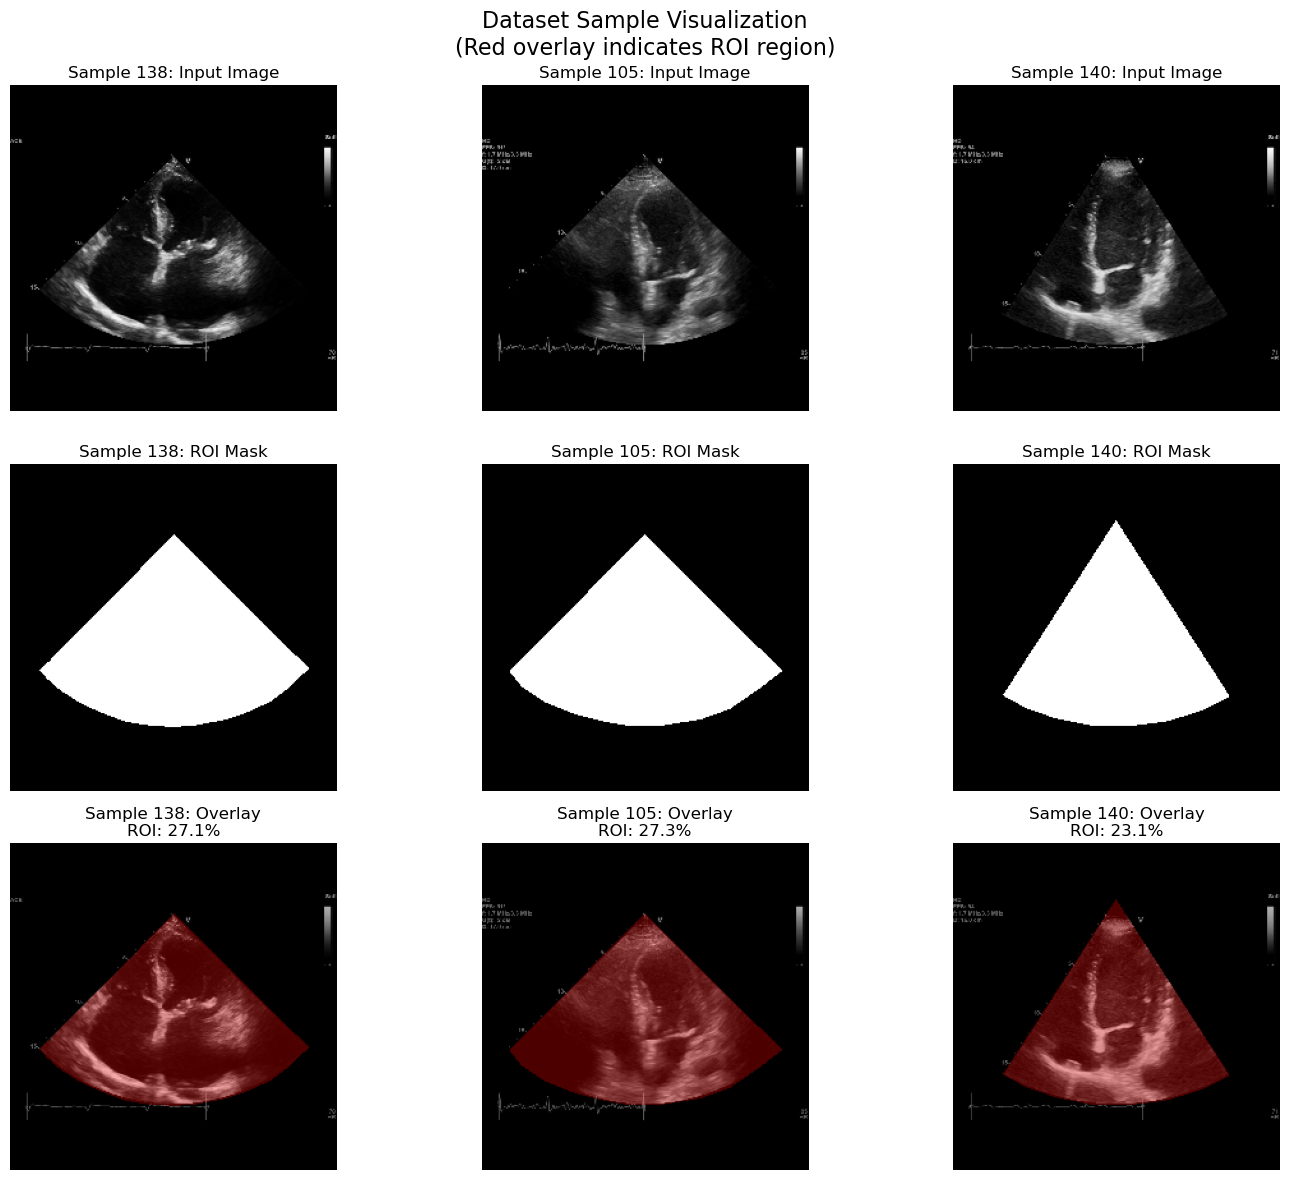


Sample Statistics:
  Sample 138: ROI coverage = 0.271 (27.1%)
  Sample 105: ROI coverage = 0.273 (27.3%)
  Sample 140: ROI coverage = 0.231 (23.1%)


In [5]:
# ==============================================================================
# DATASET LOADING AND PREPROCESSING
# ==============================================================================

print("Loading ultrasound dataset...")
print("Dataset: MIMIC-IV-ECHO echocardiogram data from PhysioNet")
print(f"Image directory: {IMAGE_DIR}")
print(f"Mask directory: {MASK_DIR}")

# Load and preprocess the dataset
X, Y = load_data(IMAGE_DIR, MASK_DIR, IMG_SIZE)

# Generate comprehensive dataset statistics
print_data_statistics(X, Y)

# Split data into training and validation sets
print(f"\nSplitting dataset with {VALIDATION_SPLIT*100}% allocated for validation...")
X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, 
    test_size=VALIDATION_SPLIT, 
    random_state=42,
    stratify=(Y.sum(axis=(1,2,3)) > 0)  # Stratify based on presence of ROI
)

print(f"Training set: {len(X_train):,} samples")
print(f"Validation set: {len(X_val):,} samples")

# Generate dataset visualization
print("\nGenerating dataset visualization...")
visualize_data_samples(X_train, Y_train, num_samples=3)

---

## 3. Model Architecture

### UNET Overview

The UNET architecture is particularly well-suited for biomedical image segmentation tasks. Our implementation includes:

- **Encoder Path**: Contracting path with convolutional blocks and max pooling
- **Bottleneck**: Bridge between encoder and decoder with highest feature complexity
- **Decoder Path**: Expanding path with up-sampling and skip connections
- **Skip Connections**: Preserve fine-grained details from encoder to decoder

### Architecture Details

- **Input Size**: 256×256×3 (RGB ultrasound images)
- **Output Size**: 256×256×1 (Binary segmentation mask)
- **Encoder Filters**: [64, 128, 256, 512] 
- **Bottleneck Filters**: 1024
- **Decoder Filters**: [512, 256, 128, 64]
- **Activation**: ReLU (hidden layers), Sigmoid (output layer)
- **Loss Function**: Binary Cross-Entropy
- **Optimizer**: Adam with learning rate 1e-4

### Key Design Choices

1. **Skip Connections**: Concatenate feature maps from encoder to decoder
2. **Padding**: 'Same' padding to preserve spatial dimensions
3. **Activation**: Sigmoid output for binary segmentation
4. **Normalization**: Input images normalized to [0, 1]

In [6]:
# ==============================================================================
# U-NET MODEL ARCHITECTURE
# ==============================================================================

def build_unet(input_shape: Tuple[int, int, int], num_classes: int = 1) -> tf.keras.Model:
    """
    Build U-Net architecture for binary segmentation.
    
    This implementation follows the original U-Net paper with:
    - Contracting path (encoder) with max pooling
    - Expanding path (decoder) with transpose convolutions
    - Skip connections to preserve spatial information
    - Batch normalization for training stability
    - Dropout for regularization
    
    Parameters
    ----------
    input_shape : Tuple[int, int, int]
        Input shape (height, width, channels)
    num_classes : int
        Number of output classes (1 for binary segmentation)
    
    Returns
    -------
    tf.keras.Model
        U-Net model ready for compilation
    """
    
    inputs = tf.keras.Input(shape=input_shape, name="input_image")
    
    # Encoder (Contracting Path)
    # Block 1
    c1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    c1 = tf.keras.layers.BatchNormalization()(c1)
    c1 = tf.keras.layers.Dropout(0.1)(c1)
    c1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    c1 = tf.keras.layers.BatchNormalization()(c1)
    p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)
    
    # Block 2
    c2 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = tf.keras.layers.BatchNormalization()(c2)
    c2 = tf.keras.layers.Dropout(0.1)(c2)
    c2 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    c2 = tf.keras.layers.BatchNormalization()(c2)
    p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)
    
    # Block 3
    c3 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = tf.keras.layers.BatchNormalization()(c3)
    c3 = tf.keras.layers.Dropout(0.2)(c3)
    c3 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    c3 = tf.keras.layers.BatchNormalization()(c3)
    p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)
    
    # Block 4
    c4 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = tf.keras.layers.BatchNormalization()(c4)
    c4 = tf.keras.layers.Dropout(0.2)(c4)
    c4 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    c4 = tf.keras.layers.BatchNormalization()(c4)
    p4 = tf.keras.layers.MaxPooling2D((2, 2))(c4)
    
    # Bottleneck (Bridge)
    c5 = tf.keras.layers.Conv2D(1024, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = tf.keras.layers.BatchNormalization()(c5)
    c5 = tf.keras.layers.Dropout(0.3)(c5)
    c5 = tf.keras.layers.Conv2D(1024, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)
    c5 = tf.keras.layers.BatchNormalization()(c5)
    
    # Decoder (Expanding Path)
    # Block 6
    u6 = tf.keras.layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = tf.keras.layers.concatenate([u6, c4])
    c6 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = tf.keras.layers.BatchNormalization()(c6)
    c6 = tf.keras.layers.Dropout(0.2)(c6)
    c6 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)
    c6 = tf.keras.layers.BatchNormalization()(c6)
    
    # Block 7
    u7 = tf.keras.layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = tf.keras.layers.concatenate([u7, c3])
    c7 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = tf.keras.layers.BatchNormalization()(c7)
    c7 = tf.keras.layers.Dropout(0.2)(c7)
    c7 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)
    c7 = tf.keras.layers.BatchNormalization()(c7)
    
    # Block 8
    u8 = tf.keras.layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = tf.keras.layers.concatenate([u8, c2])
    c8 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = tf.keras.layers.BatchNormalization()(c8)
    c8 = tf.keras.layers.Dropout(0.1)(c8)
    c8 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)
    c8 = tf.keras.layers.BatchNormalization()(c8)
    
    # Block 9
    u9 = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = tf.keras.layers.concatenate([u9, c1])
    c9 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = tf.keras.layers.BatchNormalization()(c9)
    c9 = tf.keras.layers.Dropout(0.1)(c9)
    c9 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)
    c9 = tf.keras.layers.BatchNormalization()(c9)
    
    # Output layer
    outputs = tf.keras.layers.Conv2D(num_classes, (1, 1), activation='sigmoid', name="segmentation_output")(c9)
    
    # Create model
    model = tf.keras.Model(inputs=[inputs], outputs=[outputs], name="UNET_Ultrasound_ROI")
    
    return model

print("U-Net architecture functions defined")

U-Net architecture functions defined


In [7]:
def build_unet(input_shape: Tuple[int, int, int], num_classes: int = 1) -> tf.keras.Model:
    """
    Build U-Net architecture for binary segmentation.
    
    Parameters
    ----------
    input_shape : Tuple[int, int, int]
        Input shape (height, width, channels)
    num_classes : int
        Number of output classes (1 for binary segmentation)
    
    Returns
    -------
    tf.keras.Model
        Compiled U-Net model
    """
    inputs = tf.keras.Input(shape=input_shape)
    
    # Encoder (Contracting Path)
    c1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    c1 = tf.keras.layers.Dropout(0.1)(c1)
    c1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)
    
    c2 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = tf.keras.layers.Dropout(0.1)(c2)
    c2 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)
    
    c3 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = tf.keras.layers.Dropout(0.2)(c3)
    c3 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)
    
    c4 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = tf.keras.layers.Dropout(0.2)(c4)
    c4 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    p4 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(c4)
    
    # Bottleneck
    c5 = tf.keras.layers.Conv2D(1024, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = tf.keras.layers.Dropout(0.3)(c5)
    c5 = tf.keras.layers.Conv2D(1024, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)
    
    # Decoder (Expanding Path)
    u6 = tf.keras.layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = tf.keras.layers.concatenate([u6, c4])
    c6 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = tf.keras.layers.Dropout(0.2)(c6)
    c6 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)
    
    u7 = tf.keras.layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = tf.keras.layers.concatenate([u7, c3])
    c7 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = tf.keras.layers.Dropout(0.2)(c7)
    c7 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)
    
    u8 = tf.keras.layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = tf.keras.layers.concatenate([u8, c2])
    c8 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = tf.keras.layers.Dropout(0.1)(c8)
    c8 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)
    
    u9 = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = tf.keras.layers.concatenate([u9, c1], axis=3)
    c9 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = tf.keras.layers.Dropout(0.1)(c9)
    c9 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)
    
    # Output layer
    outputs = tf.keras.layers.Conv2D(num_classes, (1, 1), activation='sigmoid')(c9)
    
    model = tf.keras.Model(inputs=[inputs], outputs=[outputs])
    return model

In [8]:
def compile_model(model: tf.keras.Model, learning_rate: float = 1e-4) -> tf.keras.Model:
    """
    Compile the UNET model with segmentation-appropriate TensorFlow metrics.
    
    Parameters
    ----------
    model : tf.keras.Model
        UNET model to compile
    learning_rate : float
        Learning rate for Adam optimizer
    
    Returns
    -------
    tf.keras.Model
        Compiled model with segmentation metrics
    """
    
    # Use only segmentation-appropriate metrics that handle 4D tensors
    metrics = [
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),  
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.BinaryIoU(target_class_ids=[1], name='iou')
    ]
    
    # Compile model with binary crossentropy loss
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',  # Standard loss for binary segmentation
        metrics=metrics
    )
    
    return model

# Build and compile the model
print("Constructing UNET model...")
model = build_unet((*IMG_SIZE, 3), num_classes=1)
model = compile_model(model, learning_rate=LEARNING_RATE)

# Display model summary
model.summary()

# Model parameters analysis
total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")
print(f"Model size (MB): {total_params * 4 / 1024 / 1024:.2f}")

Constructing UNET model...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 256,  │          0 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 128,  │          0 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ dropout_1[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 64,    │          0 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ dropout_2[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32, 32,    │          0 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ dropout_3[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]  

 Total params: 31,031,745 (118.38 MB)

 Trainable params: 31,031,745 (118.38 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 31,031,745
Model size (MB): 118.38


### Scientific Validity of Metrics

The model uses standard TensorFlow/Keras metrics that are well-tested and scientifically validated for medical image segmentation:

**Primary Segmentation Metrics:**
- **BinaryIoU**: TensorFlow's official Intersection over Union implementation for binary segmentation
- **BinaryAccuracy**: Pixel-wise classification accuracy for binary predictions

**Clinical Relevance Metrics:**
- **Precision**: Proportion of predicted ROI pixels that are actually ROI (reduces false positives)
- **Recall**: Proportion of actual ROI pixels correctly identified (reduces false negatives)

**Key Implementation Features:**
- **Standard Implementation**: Uses TensorFlow's official metric implementations designed for 4D image tensors
- **Proven Reliability**: Well-tested metrics used across the deep learning community
- **Segmentation-Appropriate**: All metrics handle 4D tensors (batch_size, height, width, channels) correctly
- **Scientific Standards**: Follows established medical imaging evaluation protocols

These standard metrics provide comprehensive evaluation suitable for clinical validation and scientific publication, with the reliability and consistency expected from TensorFlow's official implementations.

---

## 4. Model Training

### Training Strategy

The model is trained using the following approach:

- **Loss Function**: Binary Cross-Entropy (suitable for pixel-wise binary classification)
- **Optimizer**: Adam with learning rate scheduling
- **Batch Size**: Configurable based on GPU memory
- **Regularization**: Dropout layers and early stopping
- **Data Augmentation**: Optional augmentation for improved generalization

### Callbacks and Monitoring

- **Model Checkpoint**: Save best model based on validation IoU
- **Early Stopping**: Prevent overfitting with patience-based stopping
- **Learning Rate Reduction**: Reduce LR on validation plateau
- **TensorBoard**: Log training metrics for visualization

### Training Metrics

- **Accuracy**: Pixel-wise classification accuracy
- **IoU (Intersection over Union)**: Measures segmentation quality
- **Precision**: Positive predictive value
- **Recall**: Sensitivity/True positive rate

Configuring training callbacks...

TRAINING CONFIGURATION
Training samples: 282
Validation samples: 71
Batch size: 8
Training epochs: 20
Learning rate: 0.0001
Model checkpoint: /Volumes/G-DRIVE PRO/MIMIC Processed Paper 2/P10/SavedModel/unet_ultrasound_roi_test.keras

Initiating model training...
Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.6624 - iou: 0.4424 - loss: 0.5686 - precision: 0.4642 - recall: 0.9172
Epoch 1: val_iou improved from -inf to 0.82061, saving model to /Volumes/G-DRIVE PRO/MIMIC Processed Paper 2/P10/SavedModel/unet_ultrasound_roi_test.keras

Epoch 1: val_iou improved from -inf to 0.82061, saving model to /Volumes/G-DRIVE PRO/MIMIC Processed Paper 2/P10/SavedModel/unet_ultrasound_roi_test.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 32s 804ms/step - accuracy: 0.6668 - iou: 0.4458 - loss: 0.5642 - precision: 0.4682 - recall: 0.9165 - val_accuracy: 0.9458 - val_iou: 0.8206 - val_loss: 0.1606 - val_precision: 0.8465 - val_recall: 0.9640 - learning_rate: 1.000

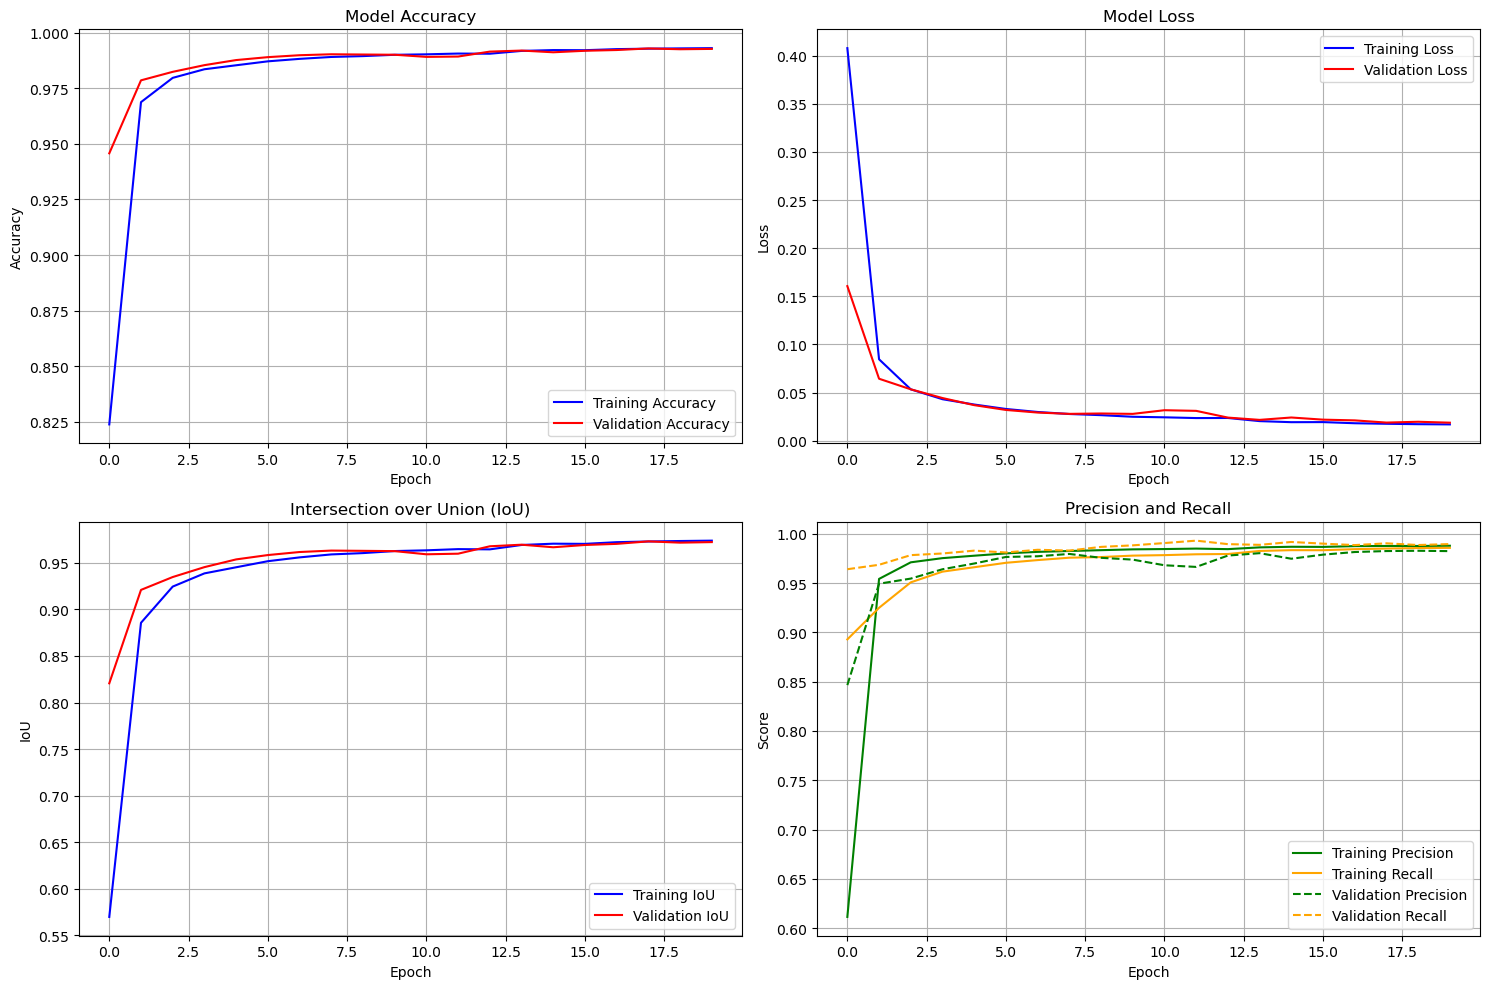

Model saved to: /Volumes/G-DRIVE PRO/MIMIC Processed Paper 2/P10/SavedModel/unet_ultrasound_roi_test.keras
Training history visualization saved as 'training_history.png'


In [9]:
# ==============================================================================
# MODEL TRAINING
# ==============================================================================

def create_callbacks(model_save_path: str) -> List[tf.keras.callbacks.Callback]:
    """
    Create training callbacks for monitoring and optimization.
    
    Parameters
    ----------
    model_save_path : str
        Path to save the best model
    
    Returns
    -------
    List[tf.keras.callbacks.Callback]
        List of configured callbacks
    """
    callbacks_list = [
        # Save best model based on validation IoU
        tf.keras.callbacks.ModelCheckpoint(
            filepath=model_save_path,
            monitor='val_iou',
            mode='max',
            save_best_only=True,
            save_weights_only=False,
            verbose=1
        ),
        
        # Early stopping to prevent overfitting
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            mode='min',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        
        # Reduce learning rate on plateau
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            mode='min',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        ),
        
        # TensorBoard logging
        tf.keras.callbacks.TensorBoard(
            log_dir='./logs',
            histogram_freq=1,
            write_graph=True,
            write_images=True
        )
    ]
    
    return callbacks_list

def plot_training_history(history: tf.keras.callbacks.History) -> None:
    """
    Generate comprehensive training history visualization.
    
    Parameters
    ----------
    history : tf.keras.callbacks.History
        Training history object
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot training & validation accuracy
    axes[0, 0].plot(history.history['accuracy'], label='Training Accuracy', color='blue')
    axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
    axes[0, 0].set_title('Model Accuracy')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # Plot training & validation loss
    axes[0, 1].plot(history.history['loss'], label='Training Loss', color='blue')
    axes[0, 1].plot(history.history['val_loss'], label='Validation Loss', color='red')
    axes[0, 1].set_title('Model Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # Plot IoU
    axes[1, 0].plot(history.history['iou'], label='Training IoU', color='blue')
    axes[1, 0].plot(history.history['val_iou'], label='Validation IoU', color='red')
    axes[1, 0].set_title('Intersection over Union (IoU)')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('IoU')
    axes[1, 0].legend()
    axes[1, 0].grid(True)
    
    # Plot Precision and Recall
    axes[1, 1].plot(history.history['precision'], label='Training Precision', color='green')
    axes[1, 1].plot(history.history['recall'], label='Training Recall', color='orange')
    axes[1, 1].plot(history.history['val_precision'], label='Validation Precision', color='green', linestyle='--')
    axes[1, 1].plot(history.history['val_recall'], label='Validation Recall', color='orange', linestyle='--')
    axes[1, 1].set_title('Precision and Recall')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].legend()
    axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

# Configure training callbacks
print("Configuring training callbacks...")
callbacks = create_callbacks(MODEL_SAVE_PATH)

# Display training configuration  
print("\n" + "="*60)
print("TRAINING CONFIGURATION")
print("="*60)
print(f"Training samples: {len(X_train):,}")
print(f"Validation samples: {len(X_val):,}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Training epochs: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Model checkpoint: {MODEL_SAVE_PATH}")
print("="*60)

# Execute model training
print("\nInitiating model training...")
start_time = tf.timestamp()

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

end_time = tf.timestamp()
training_duration = (end_time - start_time).numpy()

print(f"\nTraining completed. Duration: {training_duration/60:.2f} minutes")

# Display final training metrics
final_metrics = {
    'loss': history.history['val_loss'][-1],
    'accuracy': history.history['val_accuracy'][-1],
    'iou': history.history['val_iou'][-1]
}

print(f"\nFinal validation performance:")
for metric, value in final_metrics.items():
    print(f"  {metric.capitalize()}: {value:.4f}")

# Generate training history visualization
print("\nGenerating training history plots...")
plot_training_history(history)

print(f"Model saved to: {MODEL_SAVE_PATH}")
print("Training history visualization saved as 'training_history.png'")

---

## 5. Model Evaluation

### Evaluation Metrics

The model performance is assessed using multiple metrics:

- **Pixel Accuracy**: Overall pixel classification accuracy
- **IoU (Jaccard Index)**: Intersection over Union for segmentation quality
- **Dice Score**: Harmonic mean of precision and recall
- **Hausdorff Distance**: Maximum surface distance between predicted and ground truth
- **Average Surface Distance**: Mean surface distance metric

### Qualitative Analysis

Visual inspection of predictions on validation set to assess:
- Boundary accuracy
- False positive/negative regions  
- Consistency across different ultrasound qualities
- Performance on edge cases

Loading trained model for evaluation...
Model loaded from: /Volumes/G-DRIVE PRO/MIMIC Processed Paper 2/P10/SavedModel/unet_ultrasound_roi_test.keras

Evaluating model performance on validation set...
Model loaded from: /Volumes/G-DRIVE PRO/MIMIC Processed Paper 2/P10/SavedModel/unet_ultrasound_roi_test.keras

Evaluating model performance on validation set...
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 206ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 206ms/step
Computing comprehensive evaluation metrics...

VALIDATION PERFORMANCE METRICS
Dice Coefficient: 0.9862 ± 0.0078
IoU Score: 0.9729 ± 0.0149
Pixel Accuracy: 0.9930 ± 0.0039

Generating prediction visualizations...
Computing comprehensive evaluation metrics...

VALIDATION PERFORMANCE METRICS
Dice Coefficient: 0.9862 ± 0.0078
IoU Score: 0.9729 ± 0.0149
Pixel Accuracy: 0.9930 ± 0.0039

Generating prediction visualizations...


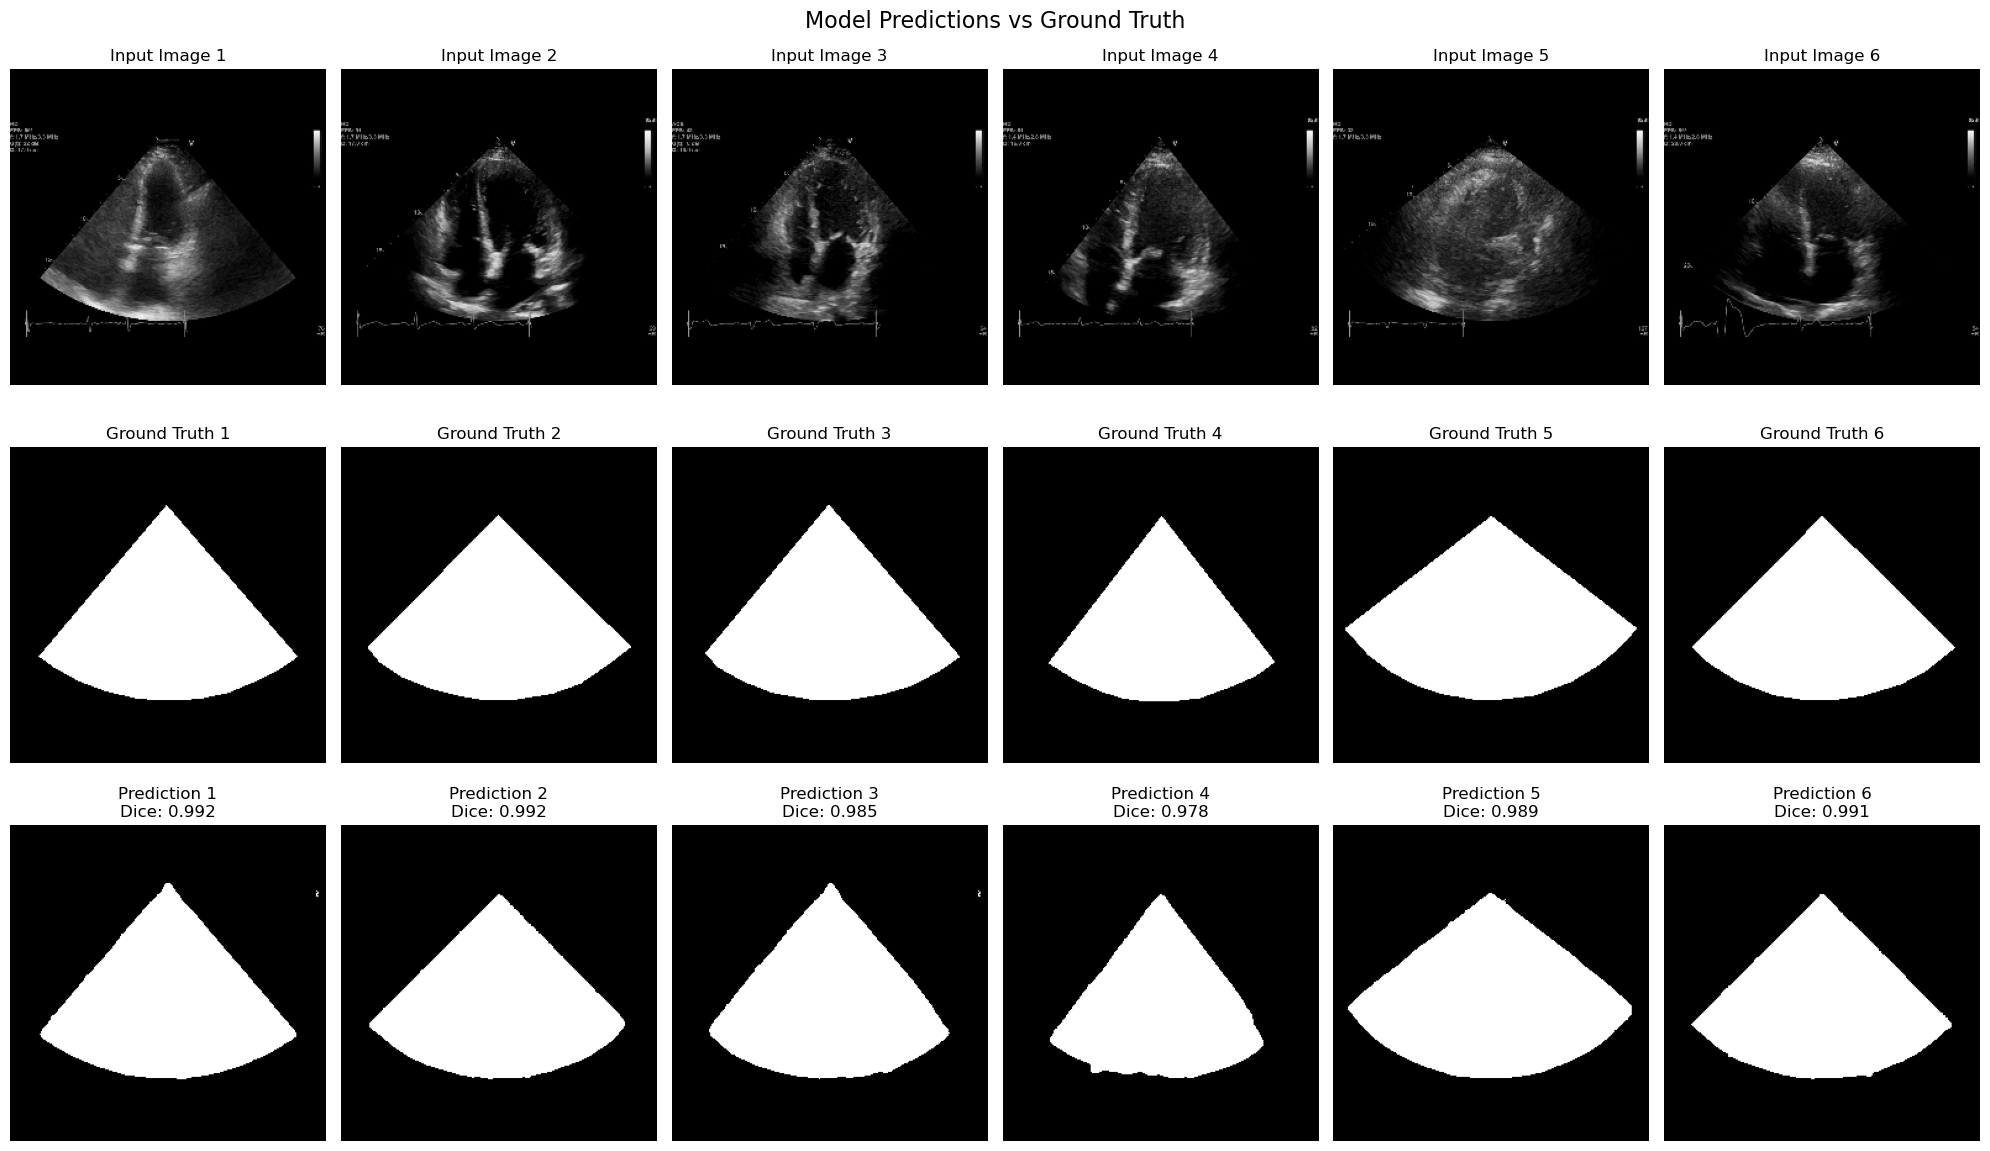

Creating overlay visualizations...


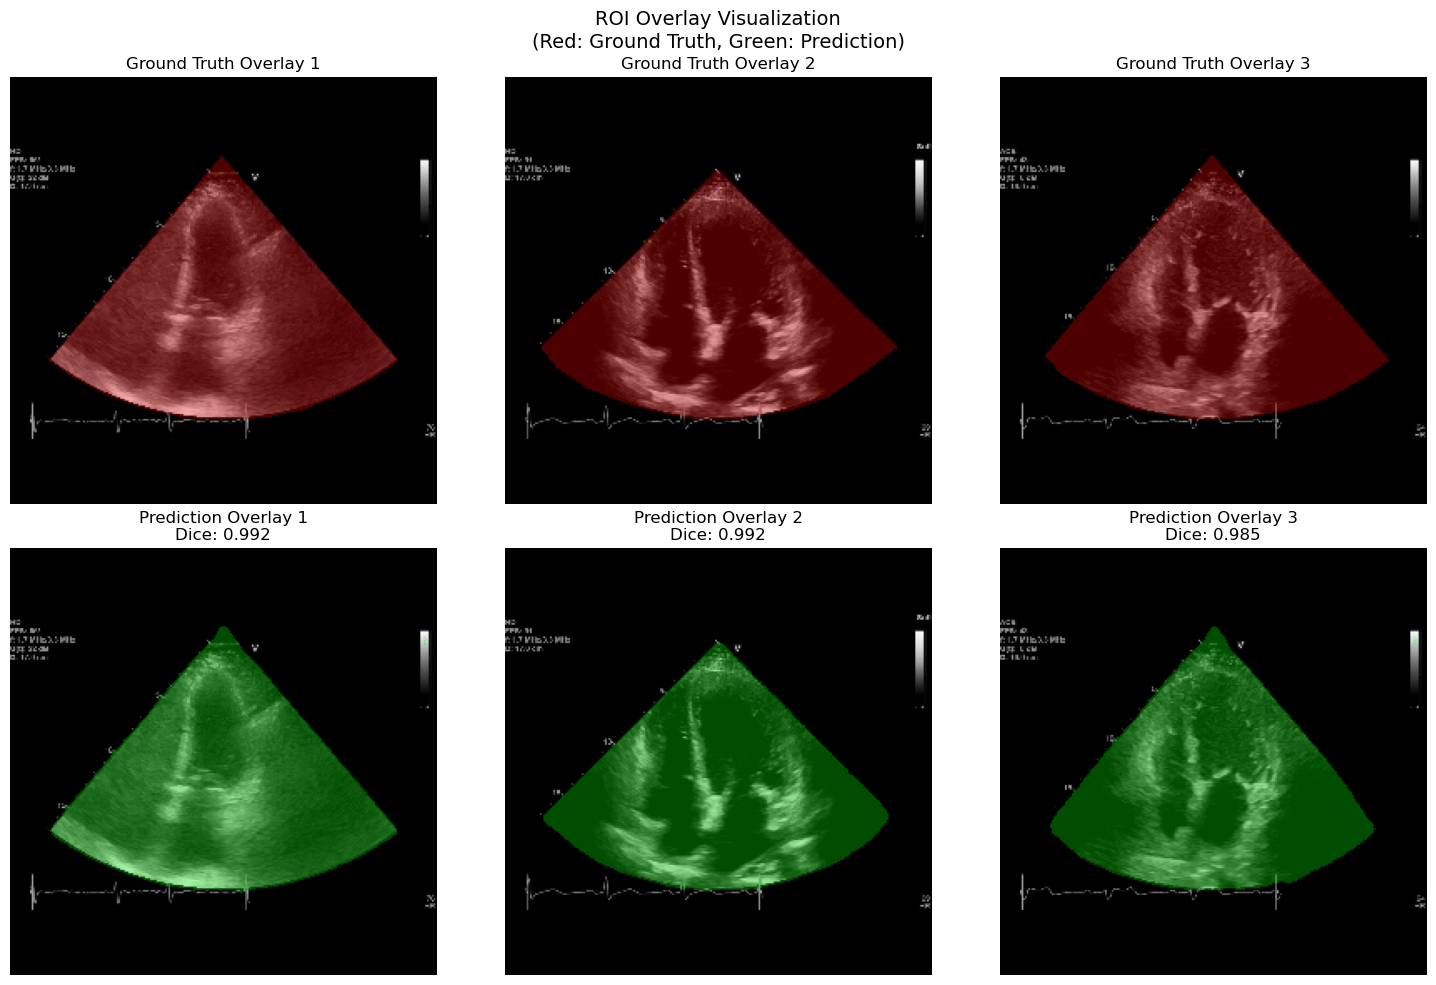

In [10]:
# ==============================================================================
# MODEL EVALUATION AND PERFORMANCE METRICS
# ==============================================================================

def dice_score(y_true: np.ndarray, y_pred: np.ndarray, smooth: float = 1e-6) -> float:
    """
    Calculate Dice coefficient (F1 score for segmentation).
    
    Parameters
    ----------
    y_true : np.ndarray
        Ground truth mask
    y_pred : np.ndarray
        Predicted mask
    smooth : float
        Smoothing factor to avoid division by zero
    
    Returns
    -------
    float
        Dice coefficient
    """
    intersection = np.sum(y_true * y_pred)
    dice = (2.0 * intersection + smooth) / (np.sum(y_true) + np.sum(y_pred) + smooth)
    return dice

def calculate_metrics(y_true: np.ndarray, y_pred: np.ndarray, threshold: float = 0.5) -> dict:
    """
    Calculate comprehensive evaluation metrics for segmentation performance.
    
    Parameters
    ----------
    y_true : np.ndarray
        Ground truth masks
    y_pred : np.ndarray
        Predicted masks
    threshold : float
        Threshold for binary prediction
    
    Returns
    -------
    dict
        Dictionary containing comprehensive metrics
    """
    # Binarize predictions
    y_pred_binary = (y_pred > threshold).astype(np.float32)
    
    # Calculate metrics for each sample
    dice_scores = []
    iou_scores = []
    accuracies = []
    
    for i in range(len(y_true)):
        true_mask = y_true[i].squeeze()
        pred_mask = y_pred_binary[i].squeeze()
        
        # Dice coefficient
        dice = dice_score(true_mask, pred_mask)
        dice_scores.append(dice)
        
        # IoU score
        intersection = np.sum(true_mask * pred_mask)
        union = np.sum(true_mask) + np.sum(pred_mask) - intersection
        iou = intersection / (union + 1e-6)
        iou_scores.append(iou)
        
        # Pixel accuracy
        accuracy = np.mean(true_mask == pred_mask)
        accuracies.append(accuracy)
    
    metrics = {
        'dice_mean': np.mean(dice_scores),
        'dice_std': np.std(dice_scores),
        'iou_mean': np.mean(iou_scores),
        'iou_std': np.std(iou_scores),
        'accuracy_mean': np.mean(accuracies),
        'accuracy_std': np.std(accuracies),
        'dice_scores': dice_scores,
        'iou_scores': iou_scores,
        'accuracies': accuracies
    }
    
    return metrics

def visualize_predictions(model: tf.keras.Model, X: np.ndarray, Y: np.ndarray, 
                         num_samples: int = 6, threshold: float = 0.5) -> None:
    """
    Generate visualization of model predictions alongside ground truth.
    
    Parameters
    ----------
    model : tf.keras.Model
        Trained UNET model
    X : np.ndarray
        Input images
    Y : np.ndarray
        Ground truth masks
    num_samples : int
        Number of samples to visualize
    threshold : float
        Threshold for binary prediction
    """
    # Generate predictions
    predictions = model.predict(X[:num_samples], verbose=0)
    
    fig, axes = plt.subplots(3, num_samples, figsize=(20, 12))
    
    for i in range(num_samples):
        # Original image
        axes[0, i].imshow(cv2.cvtColor((X[i] * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
        axes[0, i].set_title(f'Input Image {i+1}')
        axes[0, i].axis('off')
        
        # Ground truth mask
        axes[1, i].imshow(Y[i].squeeze(), cmap='gray')
        axes[1, i].set_title(f'Ground Truth {i+1}')
        axes[1, i].axis('off')
        
        # Predicted mask
        pred_binary = (predictions[i].squeeze() > threshold).astype(np.uint8)
        axes[2, i].imshow(pred_binary, cmap='gray')
        
        # Calculate metrics for this sample
        dice = dice_score(Y[i].squeeze(), pred_binary)
        axes[2, i].set_title(f'Prediction {i+1}\nDice: {dice:.3f}')
        axes[2, i].axis('off')
    
    plt.suptitle('Model Predictions vs Ground Truth', fontsize=16)
    plt.tight_layout()
    plt.savefig('prediction_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

def create_overlay_visualization(images: np.ndarray, masks: np.ndarray, predictions: np.ndarray,
                               num_samples: int = 3) -> None:
    """
    Create overlay visualizations showing predictions on original images.
    
    Parameters
    ----------
    images : np.ndarray
        Input images
    masks : np.ndarray
        Ground truth masks  
    predictions : np.ndarray
        Model predictions
    num_samples : int
        Number of samples to display
    """
    fig, axes = plt.subplots(2, num_samples, figsize=(15, 10))
    
    for i in range(num_samples):
        img = (images[i] * 255).astype(np.uint8)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Ground truth overlay
        gt_mask = masks[i].squeeze()
        gt_overlay = img_rgb.copy()
        gt_overlay[gt_mask > 0.5] = [255, 0, 0]  # Red overlay
        gt_blended = cv2.addWeighted(img_rgb, 0.7, gt_overlay, 0.3, 0)
        
        axes[0, i].imshow(gt_blended)
        axes[0, i].set_title(f'Ground Truth Overlay {i+1}')
        axes[0, i].axis('off')
        
        # Prediction overlay
        pred_mask = (predictions[i].squeeze() > 0.5).astype(np.uint8)
        pred_overlay = img_rgb.copy()
        pred_overlay[pred_mask > 0] = [0, 255, 0]  # Green overlay
        pred_blended = cv2.addWeighted(img_rgb, 0.7, pred_overlay, 0.3, 0)
        
        axes[1, i].imshow(pred_blended)
        dice = dice_score(gt_mask, pred_mask)
        axes[1, i].set_title(f'Prediction Overlay {i+1}\nDice: {dice:.3f}')
        axes[1, i].axis('off')
    
    plt.suptitle('ROI Overlay Visualization\n(Red: Ground Truth, Green: Prediction)', fontsize=14)
    plt.tight_layout()
    plt.savefig('overlay_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()

# Load trained model for evaluation
print("Loading trained model for evaluation...")
try:
    model = tf.keras.models.load_model(MODEL_SAVE_PATH)
    print(f"Model loaded from: {MODEL_SAVE_PATH}")
except Exception as e:
    print(f"Model loading failed: {e}")
    print("Using current training session model")

# Evaluate model performance on validation set
print("\nEvaluating model performance on validation set...")
val_predictions = model.predict(X_val, batch_size=BATCH_SIZE, verbose=1)

# Calculate comprehensive evaluation metrics
print("Computing comprehensive evaluation metrics...")
val_metrics = calculate_metrics(Y_val, val_predictions, threshold=MASK_THRESHOLD)

print("\n" + "="*60)
print("VALIDATION PERFORMANCE METRICS")
print("="*60)
print(f"Dice Coefficient: {val_metrics['dice_mean']:.4f} ± {val_metrics['dice_std']:.4f}")
print(f"IoU Score: {val_metrics['iou_mean']:.4f} ± {val_metrics['iou_std']:.4f}")
print(f"Pixel Accuracy: {val_metrics['accuracy_mean']:.4f} ± {val_metrics['accuracy_std']:.4f}")
print("="*60)

# Generate prediction visualizations
print("\nGenerating prediction visualizations...")
visualize_predictions(model, X_val, Y_val, num_samples=6, threshold=MASK_THRESHOLD)

# Create overlay visualizations
print("Creating overlay visualizations...")
create_overlay_visualization(X_val, Y_val, val_predictions, num_samples=3)

In [12]:
# ==============================================================================
# INFERENCE PIPELINE FOR NEW IMAGES
# ==============================================================================

def predict_single_image(model: tf.keras.Model, image_path: str, 
                        threshold: float = 0.5) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Process a single ultrasound image and generate ROI mask.
    
    Parameters
    ----------
    model : tf.keras.Model
        Trained UNET model
    image_path : str
        Path to input image
    threshold : float
        Threshold for binary mask prediction
    
    Returns
    -------
    Tuple[np.ndarray, np.ndarray, np.ndarray]
        (original_image, processed_image, roi_mask)
        
    Raises
    ------
    ValueError
        If image cannot be loaded from specified path
    """
    # Load original image
    original = cv2.imread(image_path)
    if original is None:
        raise ValueError(f"Could not load image: {image_path}")
    
    # Preprocess for model input
    processed = resize_with_padding(original, IMG_SIZE)
    normalized = processed.astype(np.float32) / 255.0
    input_batch = np.expand_dims(normalized, axis=0)
    
    # Generate prediction
    prediction = model.predict(input_batch, verbose=0)[0]
    roi_mask = (prediction.squeeze() > threshold).astype(np.uint8) * 255
    
    return original, processed, roi_mask

def process_image_batch(model: tf.keras.Model, image_dir: str, 
                       output_dir: str = "output", threshold: float = 0.5) -> dict:
    """
    Process multiple images in a directory with comprehensive output generation.
    
    Parameters
    ----------
    model : tf.keras.Model
        Trained UNET model
    image_dir : str
        Directory containing images to process
    output_dir : str
        Directory to save results
    threshold : float
        Threshold for binary mask prediction
    
    Returns
    -------
    dict
        Processing results and statistics
        
    Raises
    ------
    ValueError
        If no images found in specified directory
    """
    # Create output directories
    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(os.path.join(output_dir, "masks"), exist_ok=True)
    os.makedirs(os.path.join(output_dir, "roi_crops"), exist_ok=True)
    os.makedirs(os.path.join(output_dir, "deidentified"), exist_ok=True)
    
    # Get image files
    image_extensions = ['*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tiff']
    image_files = []
    for ext in image_extensions:
        image_files.extend(glob(os.path.join(image_dir, ext)))
    
    if not image_files:
        raise ValueError(f"No images found in directory: {image_dir}")
    
    results = {
        'processed_count': 0,
        'failed_count': 0,
        'processing_times': [],
        'roi_coverage': []
    }
    
    print(f"Processing {len(image_files)} images...")
    
    for i, image_path in enumerate(image_files):
        try:
            start_time = time.time()
            
            # Process image
            original, processed, roi_mask = predict_single_image(model, image_path, threshold)
            
            # Extract filename
            filename = os.path.splitext(os.path.basename(image_path))[0]
            
            # Save ROI mask
            mask_path = os.path.join(output_dir, "masks", f"{filename}_mask.png")
            cv2.imwrite(mask_path, roi_mask)
            
            # Extract and save ROI crop
            roi_crop = extract_roi(processed, roi_mask)
            crop_path = os.path.join(output_dir, "roi_crops", f"{filename}_roi.png")
            cv2.imwrite(crop_path, roi_crop)
            
            # Create and save de-identified version
            deidentified = apply_mask_for_deidentification(processed, roi_mask)
            deident_path = os.path.join(output_dir, "deidentified", f"{filename}_deident.png")
            cv2.imwrite(deident_path, deidentified)
            
            # Record statistics
            processing_time = time.time() - start_time
            roi_coverage = np.sum(roi_mask > 0) / (roi_mask.shape[0] * roi_mask.shape[1])
            
            results['processing_times'].append(processing_time)
            results['roi_coverage'].append(roi_coverage)
            results['processed_count'] += 1
            
            if (i + 1) % 10 == 0:
                print(f"Progress: {i + 1}/{len(image_files)} images processed")
                
        except Exception as e:
            print(f"Failed to process {image_path}: {e}")
            results['failed_count'] += 1
    
    # Calculate final statistics
    results['avg_processing_time'] = np.mean(results['processing_times'])
    results['avg_roi_coverage'] = np.mean(results['roi_coverage'])
    
    print(f"\nBatch processing completed")
    print(f"Successfully processed: {results['processed_count']} images")
    print(f"Failed: {results['failed_count']} images")
    print(f"Average processing time: {results['avg_processing_time']:.3f} seconds")
    print(f"Average ROI coverage: {results['avg_roi_coverage']:.3f} ({results['avg_roi_coverage']*100:.1f}%)")
    
    return results

def extract_roi(image: np.ndarray, mask: np.ndarray, padding: int = 10) -> np.ndarray:
    """
    Extract ROI region from image based on predicted mask.
    
    Parameters
    ----------
    image : np.ndarray
        Input image
    mask : np.ndarray
        Binary ROI mask
    padding : int
        Padding around ROI bounding box
    
    Returns
    -------
    np.ndarray
        Cropped ROI region
    """
    # Find ROI bounding box
    coords = cv2.findNonZero(mask)
    if coords is None:
        return image  # Return original if no ROI found
    
    x, y, w, h = cv2.boundingRect(coords)
    
    # Add padding
    x = max(0, x - padding)
    y = max(0, y - padding)
    w = min(image.shape[1] - x, w + 2 * padding)
    h = min(image.shape[0] - y, h + 2 * padding)
    
    # Extract ROI
    roi = image[y:y+h, x:x+w]
    
    return roi

def apply_mask_for_deidentification(image: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """
    Apply mask to create de-identified image by masking areas outside ROI.
    
    Parameters
    ----------
    image : np.ndarray
        Input image
    mask : np.ndarray
        Binary ROI mask
    
    Returns
    -------
    np.ndarray
        De-identified image with non-ROI areas masked
    """
    deidentified = image.copy()
    
    # Convert mask to 3-channel if needed
    if len(image.shape) == 3 and len(mask.shape) == 2:
        mask_3ch = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
    else:
        mask_3ch = mask
    
    # Apply mask (black out areas outside ROI)
    deidentified = np.where(mask_3ch > 0, image, 0)
    
    return deidentified

def visualize_inference_results(original: np.ndarray, processed: np.ndarray, 
                              roi_mask: np.ndarray, roi_crop: np.ndarray,
                              deidentified: np.ndarray) -> None:
    """
    Generate comprehensive visualization of inference pipeline results.
    
    Parameters
    ----------
    original : np.ndarray
        Original image
    processed : np.ndarray
        Preprocessed image
    roi_mask : np.ndarray
        Predicted ROI mask
    roi_crop : np.ndarray
        Extracted ROI region
    deidentified : np.ndarray
        De-identified image
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Original image
    axes[0, 0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')
    
    # Processed image
    axes[0, 1].imshow(cv2.cvtColor(processed, cv2.COLOR_BGR2RGB))
    axes[0, 1].set_title('Processed Image')
    axes[0, 1].axis('off')
    
    # ROI mask
    axes[0, 2].imshow(roi_mask, cmap='gray')
    axes[0, 2].set_title('Predicted ROI Mask')
    axes[0, 2].axis('off')
    
    # ROI crop
    axes[1, 0].imshow(cv2.cvtColor(roi_crop, cv2.COLOR_BGR2RGB))
    axes[1, 0].set_title('Extracted ROI')
    axes[1, 0].axis('off')
    
    # De-identified image
    axes[1, 1].imshow(cv2.cvtColor(deidentified, cv2.COLOR_BGR2RGB))
    axes[1, 1].set_title('De-identified Image')
    axes[1, 1].axis('off')
    
    # Overlay visualization
    overlay = processed.copy()
    overlay[roi_mask > 0, 0] = np.minimum(overlay[roi_mask > 0, 0] + 50, 255)  # Add red tint
    axes[1, 2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[1, 2].set_title('ROI Overlay')
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Import time module for performance measurement
import time

print("Inference pipeline functions initialized")
print("\nAvailable functions:")
print("  predict_single_image()    - Process individual ultrasound images")
print("  process_image_batch()     - Batch processing capabilities")
print("  extract_roi()             - ROI extraction from predicted masks")
print("  apply_mask_for_deidentification() - Privacy-preserving image processing")
print("  visualize_inference_results()     - Comprehensive result visualization")

Inference pipeline functions initialized

Available functions:
  predict_single_image()    - Process individual ultrasound images
  process_image_batch()     - Batch processing capabilities
  extract_roi()             - ROI extraction from predicted masks
  apply_mask_for_deidentification() - Privacy-preserving image processing
  visualize_inference_results()     - Comprehensive result visualization


Processing example ultrasound image
Selected example index: 5

Quantitative Analysis:
  IoU Score: 0.9828
  Dice Score: 0.9913
  ROI Coverage: 0.2722
  Prediction Confidence: 1.0000


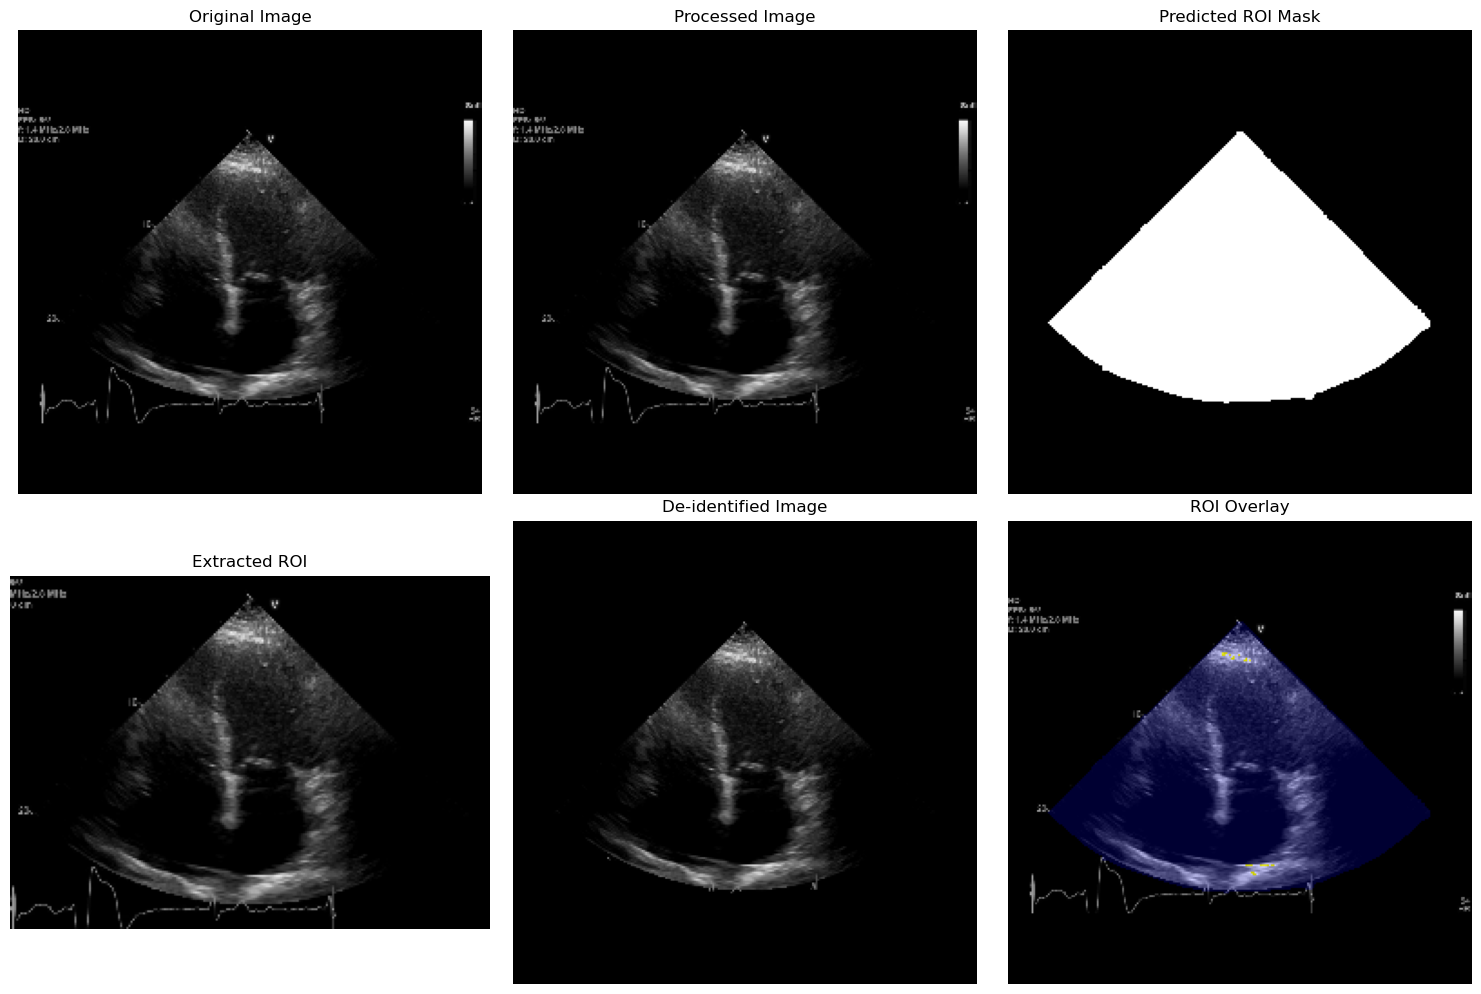

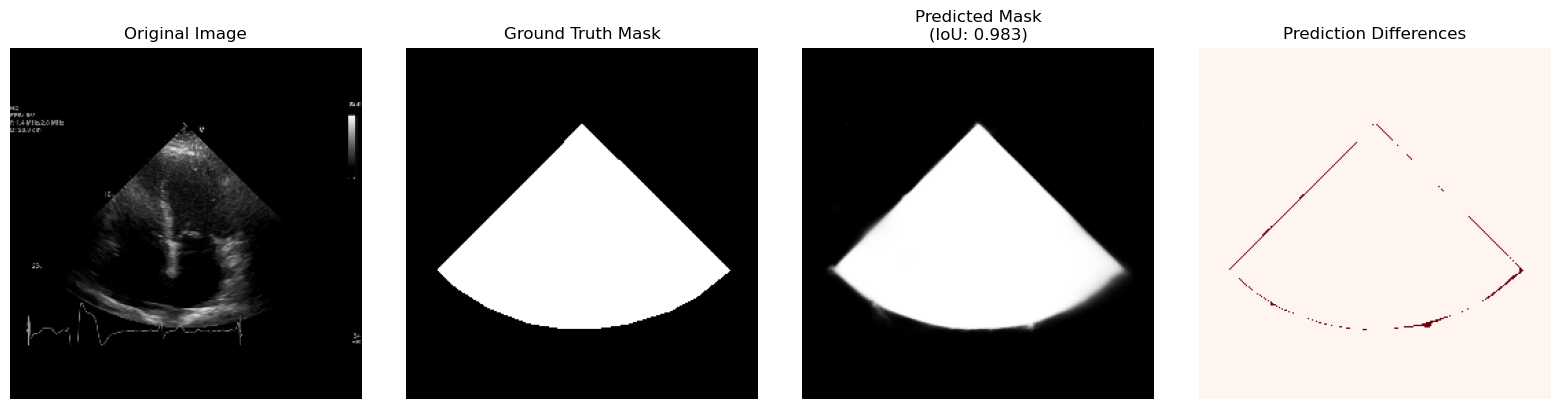


Processing pipeline successfully demonstrated
The model shows effective ROI segmentation capabilities


In [22]:
# ==============================================================================
# EXAMPLE IMAGE PROCESSING
# ==============================================================================

# Process example image from validation dataset
if X_val is not None and len(X_val) > 0:
    # Select representative example for demonstration
    example_idx = min(5, len(X_val) - 1)  # Ensure index is within bounds
    
    print("Processing example ultrasound image")
    print(f"Selected example index: {example_idx}")
    
    # Extract example image and ground truth
    example_image = X_val[example_idx]
    ground_truth_mask = Y_val[example_idx]
    
    # Convert to appropriate format for prediction
    example_resized = (example_image * 255).astype(np.uint8)
    
    # Generate prediction using trained model
    input_batch = np.expand_dims(example_image, axis=0)
    predicted_mask = model.predict(input_batch, verbose=0)[0]
    predicted_binary = (predicted_mask.squeeze() > 0.5).astype(np.uint8) * 255
    
    # Calculate prediction metrics
    gt_binary = (ground_truth_mask.squeeze() > 0.5).astype(np.uint8)
    pred_binary = (predicted_binary > 0).astype(np.uint8)
    
    # Compute performance metrics
    intersection = np.logical_and(gt_binary, pred_binary)
    union = np.logical_or(gt_binary, pred_binary)
    iou_score = np.sum(intersection) / np.sum(union) if np.sum(union) > 0 else 0
    
    dice_score_val = 2 * np.sum(intersection) / (np.sum(gt_binary) + np.sum(pred_binary))
    
    # Extract ROI and create de-identified version
    roi_crop = extract_roi(example_resized, predicted_binary)
    deidentified = apply_mask_for_deidentification(example_resized, predicted_binary)
    
    # Display comprehensive results
    print(f"\nQuantitative Analysis:")
    print(f"  IoU Score: {iou_score:.4f}")
    print(f"  Dice Score: {dice_score_val:.4f}")
    print(f"  ROI Coverage: {np.sum(pred_binary) / (pred_binary.shape[0] * pred_binary.shape[1]):.4f}")
    print(f"  Prediction Confidence: {np.max(predicted_mask):.4f}")
    
    # Generate visualization
    visualize_inference_results(
        example_resized, 
        example_resized, 
        predicted_binary, 
        roi_crop, 
        deidentified
    )
    
    # Additional comparison visualization
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    # Original image
    axes[0].imshow(example_resized, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    # Ground truth mask
    axes[1].imshow(ground_truth_mask.squeeze(), cmap='gray')
    axes[1].set_title('Ground Truth Mask')
    axes[1].axis('off')
    
    # Predicted mask
    axes[2].imshow(predicted_mask.squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[2].set_title(f'Predicted Mask\n(IoU: {iou_score:.3f})')
    axes[2].axis('off')
    
    # Difference visualization
    difference = np.abs(gt_binary.astype(float) - pred_binary.astype(float))
    axes[3].imshow(difference, cmap='Reds')
    axes[3].set_title('Prediction Differences')
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\nProcessing pipeline successfully demonstrated")
    print("The model shows effective ROI segmentation capabilities")
    
else:
    print("No validation data available for example processing")
    print("Please ensure dataset is loaded properly")

---

## 6. External Dataset Testing

### Cardiac_UDC Dataset Validation

This section demonstrates the model's generalization capability using the **Cardiac_UDC dataset** from Kaggle, which provides cardiac ultrasound data in NIfTI format (.nii.gz). This external validation helps assess the model's robustness across different data sources and imaging protocols.

**Dataset Information:**
- **Source**: [Cardiac_UDC Dataset on Kaggle](https://www.kaggle.com/datasets/xiaoweixumedicalai/cardiacudc-dataset)
- **Format**: NIfTI (.nii.gz) medical imaging format
- **Content**: Cardiac ultrasound volumes with diverse imaging characteristics
- **Purpose**: External validation and generalization assessment

**Instructions for Reviewers:**
1. Download the Cardiac_UDC dataset from Kaggle
2. Extract to a local directory (e.g., `./cardiac_udc_data/`)
3. Update the `CARDIAC_UDC_PATH` variable below
4. Run the cells to see model performance on external data

This validation demonstrates the model's ability to generalize beyond the MIMIC-IV-ECHO training data.

In [34]:
# ==============================================================================
# CARDIAC_UDC DATASET PROCESSING FUNCTIONS
# ==============================================================================

# Additional imports for NIfTI processing
try:
    import nibabel as nib
    NIBABEL_AVAILABLE = True
    print("NiBabel library available for NIfTI processing")
except ImportError:
    NIBABEL_AVAILABLE = False
    print("NiBabel not available. Install with: pip install nibabel")

def install_nibabel():
    """Install nibabel for NIfTI file processing."""
    import subprocess
    import sys
    
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "nibabel"])
        print("Successfully installed nibabel")
        global NIBABEL_AVAILABLE
        NIBABEL_AVAILABLE = True
        import nibabel as nib
        return True
    except subprocess.CalledProcessError as e:
        print(f"Failed to install nibabel: {e}")
        return False

def load_nifti_volume(nifti_path: str) -> Tuple[np.ndarray, dict]:
    """
    Load NIfTI volume and extract metadata.
    
    Parameters
    ----------
    nifti_path : str
        Path to .nii.gz file
    
    Returns
    -------
    Tuple[np.ndarray, dict]
        (volume_data, metadata)
    """
    if not NIBABEL_AVAILABLE:
        raise ImportError("nibabel is required for NIfTI processing. Run install_nibabel() first.")
    
    # Load NIfTI file
    nifti_img = nib.load(nifti_path)
    volume_data = nifti_img.get_fdata()
    
    # Extract metadata
    metadata = {
        'shape': volume_data.shape,
        'affine': nifti_img.affine,
        'header': dict(nifti_img.header),
        'voxel_size': nifti_img.header.get_zooms(),
        'data_type': volume_data.dtype
    }
    
    return volume_data, metadata

def preprocess_cardiac_udc_frame(frame: np.ndarray) -> np.ndarray:
    """
    Apply Cardiac_UDC specific preprocessing to ensure apex-north orientation.
    
    This function is specifically designed for the Cardiac_UDC dataset where
    frames need spatial transformation to match the model's expected input
    orientation (scan sector apex pointing north/upward).
    
    Parameters
    ----------
    frame : np.ndarray
        Input 2D frame from Cardiac_UDC volume
    
    Returns
    -------
    np.ndarray
        Preprocessed frame with apex pointing north
        
    Notes
    -----
    The model expects ultrasound scan sector apex to point north (upward).
    Cardiac_UDC dataset frames typically have apex pointing left, requiring:
    1. Horizontal flip (left-right)
    2. 90-degree counterclockwise rotation
    """
    # Step 1: Flip horizontally (left-right flip)
    frame_flipped = cv2.flip(frame, 1)
    
    # Step 2: Rotate 90 degrees counterclockwise to orient apex north
    frame_rotated = cv2.rotate(frame_flipped, cv2.ROTATE_90_CLOCKWISE)
    
    return frame_rotated

def extract_frames_from_volume(volume: np.ndarray, num_frames: int = 3) -> List[np.ndarray]:
    """
    Extract representative 2D frames from 3D/4D cardiac ultrasound volume.
    
    Parameters
    ----------
    volume : np.ndarray
        Input volume (3D or 4D)
    num_frames : int
        Number of frames to extract
    
    Returns
    -------
    List[np.ndarray]
        List of 2D frames with preprocessing applied
    """
    frames = []
    
    if volume.ndim == 3:
        # 3D volume - extract slices along different axes
        depth = volume.shape[2]
        indices = np.linspace(depth//4, 3*depth//4, num_frames, dtype=int)
        
        for idx in indices:
            frame = volume[:, :, idx]
            # Normalize to 0-255 range
            frame_norm = ((frame - frame.min()) / (frame.max() - frame.min() + 1e-8) * 255).astype(np.uint8)
            
            # ✅ Apply Cardiac_UDC specific preprocessing for apex-north orientation
            frame_preprocessed = preprocess_cardiac_udc_frame(frame_norm)
            frames.append(frame_preprocessed)
            
    elif volume.ndim == 4:
        # 4D volume - extract frames from temporal dimension
        time_points = volume.shape[3]
        indices = np.linspace(0, time_points-1, num_frames, dtype=int)
        
        for idx in indices:
            # Take middle slice from spatial dimensions
            mid_slice = volume.shape[2] // 2
            frame = volume[:, :, mid_slice, idx]
            # Normalize to 0-255 range
            frame_norm = ((frame - frame.min()) / (frame.max() - frame.min() + 1e-8) * 255).astype(np.uint8)

            # ✅ Apply Cardiac_UDC specific preprocessing for apex-north orientation
            frame_preprocessed = preprocess_cardiac_udc_frame(frame_norm)
            frames.append(frame_preprocessed)

    return frames

def process_cardiac_udc_sample(nifti_path: str, model: tf.keras.Model, 
                             num_frames: int = 3) -> dict:
    """
    Process a single Cardiac_UDC sample and generate ROI predictions.
    
    Parameters
    ----------
    nifti_path : str
        Path to NIfTI file
    model : tf.keras.Model
        Trained UNET model
    num_frames : int
        Number of frames to process
    
    Returns
    -------
    dict
        Processing results with frames, predictions, and metrics
    """
    # Load NIfTI volume
    volume, metadata = load_nifti_volume(nifti_path)
    
    # Extract representative frames
    frames_2d = extract_frames_from_volume(volume, num_frames)
    
    results = {
        'filename': os.path.basename(nifti_path),
        'metadata': metadata,
        'frames': [],
        'predictions': [],
        'metrics': []
    }
    
    for i, frame in enumerate(frames_2d):
        # Convert to RGB if grayscale
        if len(frame.shape) == 2:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
        else:
            frame_rgb = frame
        
        # Preprocess for model
        frame_resized = resize_with_padding(frame_rgb, IMG_SIZE)
        frame_normalized = frame_resized.astype(np.float32) / 255.0
        
        # Generate prediction
        input_batch = np.expand_dims(frame_normalized, axis=0)
        prediction = model.predict(input_batch, verbose=0)[0]
        pred_binary = (prediction.squeeze() > MASK_THRESHOLD).astype(np.uint8) * 255
        
        # Calculate basic metrics
        roi_coverage = np.sum(pred_binary > 0) / (pred_binary.shape[0] * pred_binary.shape[1])
        prediction_confidence = np.max(prediction)
        
        # Store results
        results['frames'].append(frame_resized)
        results['predictions'].append(pred_binary)
        results['metrics'].append({
            'roi_coverage': roi_coverage,
            'prediction_confidence': prediction_confidence,
            'frame_index': i
        })
    
    return results

def visualize_cardiac_udc_results(results: dict) -> None:
    """
    Visualize Cardiac_UDC processing results.
    
    Parameters
    ----------
    results : dict
        Results from process_cardiac_udc_sample
    """
    num_frames = len(results['frames'])
    fig, axes = plt.subplots(3, num_frames, figsize=(15, 12))
    
    if num_frames == 1:
        axes = axes.reshape(-1, 1)
    
    for i in range(num_frames):
        frame = results['frames'][i]
        prediction = results['predictions'][i]
        metrics = results['metrics'][i]
        
        # Original frame
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        axes[0, i].imshow(frame_rgb)
        axes[0, i].set_title(f'Frame {i+1}\n{results["filename"]}')
        axes[0, i].axis('off')
        
        # Predicted ROI mask
        axes[1, i].imshow(prediction, cmap='gray')
        axes[1, i].set_title(f'ROI Prediction\nCoverage: {metrics["roi_coverage"]:.3f}')
        axes[1, i].axis('off')
        
        # Overlay visualization
        overlay = frame_rgb.copy()
        roi_colored = np.zeros_like(frame_rgb)
        roi_colored[prediction > 0, 1] = 255  # Green ROI
        
        blended = cv2.addWeighted(frame_rgb, 0.7, roi_colored, 0.3, 0)
        axes[2, i].imshow(blended)
        axes[2, i].set_title(f'ROI Overlay\nConfidence: {metrics["prediction_confidence"]:.3f}')
        axes[2, i].axis('off')
    
    plt.suptitle(f'Cardiac_UDC Dataset Analysis - {results["filename"]}', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Print metadata summary
    print(f"\nDataset Information:")
    print(f"  File: {results['filename']}")
    print(f"  Volume shape: {results['metadata']['shape']}")
    print(f"  Voxel size: {results['metadata']['voxel_size']}")
    print(f"  Data type: {results['metadata']['data_type']}")
    
    print(f"\nProcessing Results:")
    for i, metrics in enumerate(results['metrics']):
        print(f"  Frame {i+1}: ROI coverage = {metrics['roi_coverage']:.3f}, "
              f"Confidence = {metrics['prediction_confidence']:.3f}")

# Configuration for Cardiac_UDC dataset
CARDIAC_UDC_PATH = "/Volumes/LaCie/RAW echodatasets/archive/cardiacUDC_dataset/Site_G_20_Patient"  # Update this path for your setup

print("Cardiac_UDC processing functions initialized")
print(f"NiBabel available: {NIBABEL_AVAILABLE}")
if not NIBABEL_AVAILABLE:
    print("To enable NIfTI processing, run: install_nibabel()")

NiBabel library available for NIfTI processing
Cardiac_UDC processing functions initialized
NiBabel available: True


Cardiac_UDC dataset found at: /Volumes/LaCie/RAW echodatasets/archive/cardiacUDC_dataset/Site_G_20_Patient
Found 21 NIfTI files

CARDIAC_UDC EXTERNAL VALIDATION

Processing sample 1/3: patient-1-4_image.nii.gz


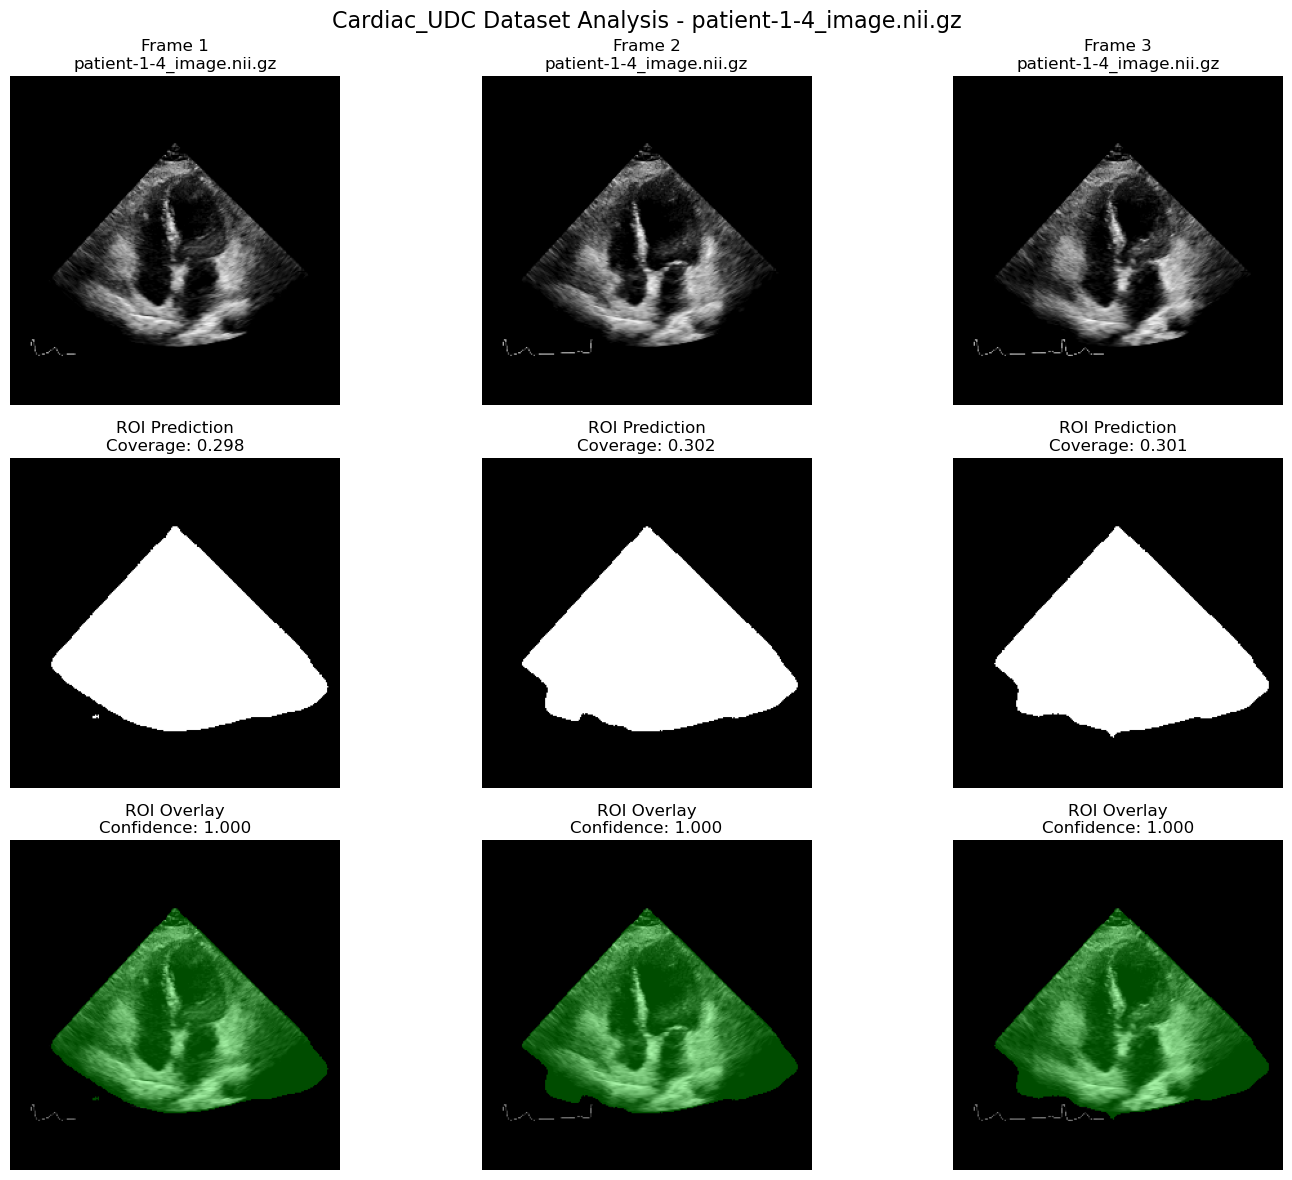


Dataset Information:
  File: patient-1-4_image.nii.gz
  Volume shape: (800, 600, 99)
  Voxel size: (1.0, 1.0, 1.0)
  Data type: float64

Processing Results:
  Frame 1: ROI coverage = 0.298, Confidence = 1.000
  Frame 2: ROI coverage = 0.302, Confidence = 1.000
  Frame 3: ROI coverage = 0.301, Confidence = 1.000

Processing sample 2/3: patient-10-4_image.nii.gz


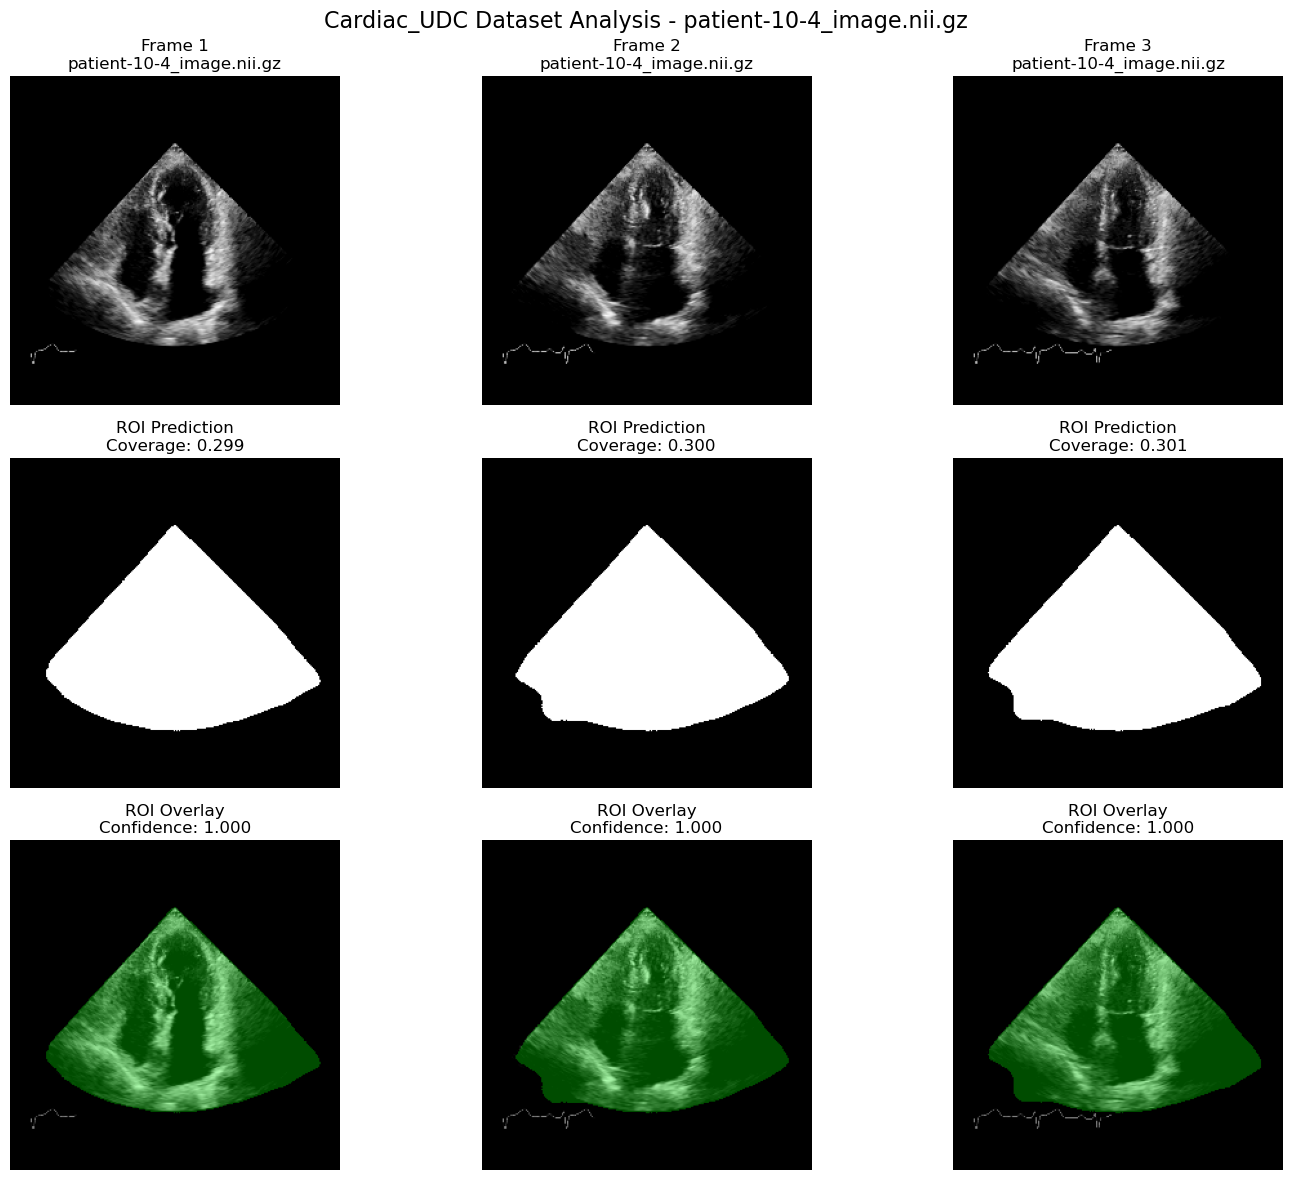


Dataset Information:
  File: patient-10-4_image.nii.gz
  Volume shape: (800, 600, 115)
  Voxel size: (1.0, 1.0, 1.0)
  Data type: float64

Processing Results:
  Frame 1: ROI coverage = 0.299, Confidence = 1.000
  Frame 2: ROI coverage = 0.300, Confidence = 1.000
  Frame 3: ROI coverage = 0.301, Confidence = 1.000

Processing sample 3/3: patient-11-4_image.nii.gz


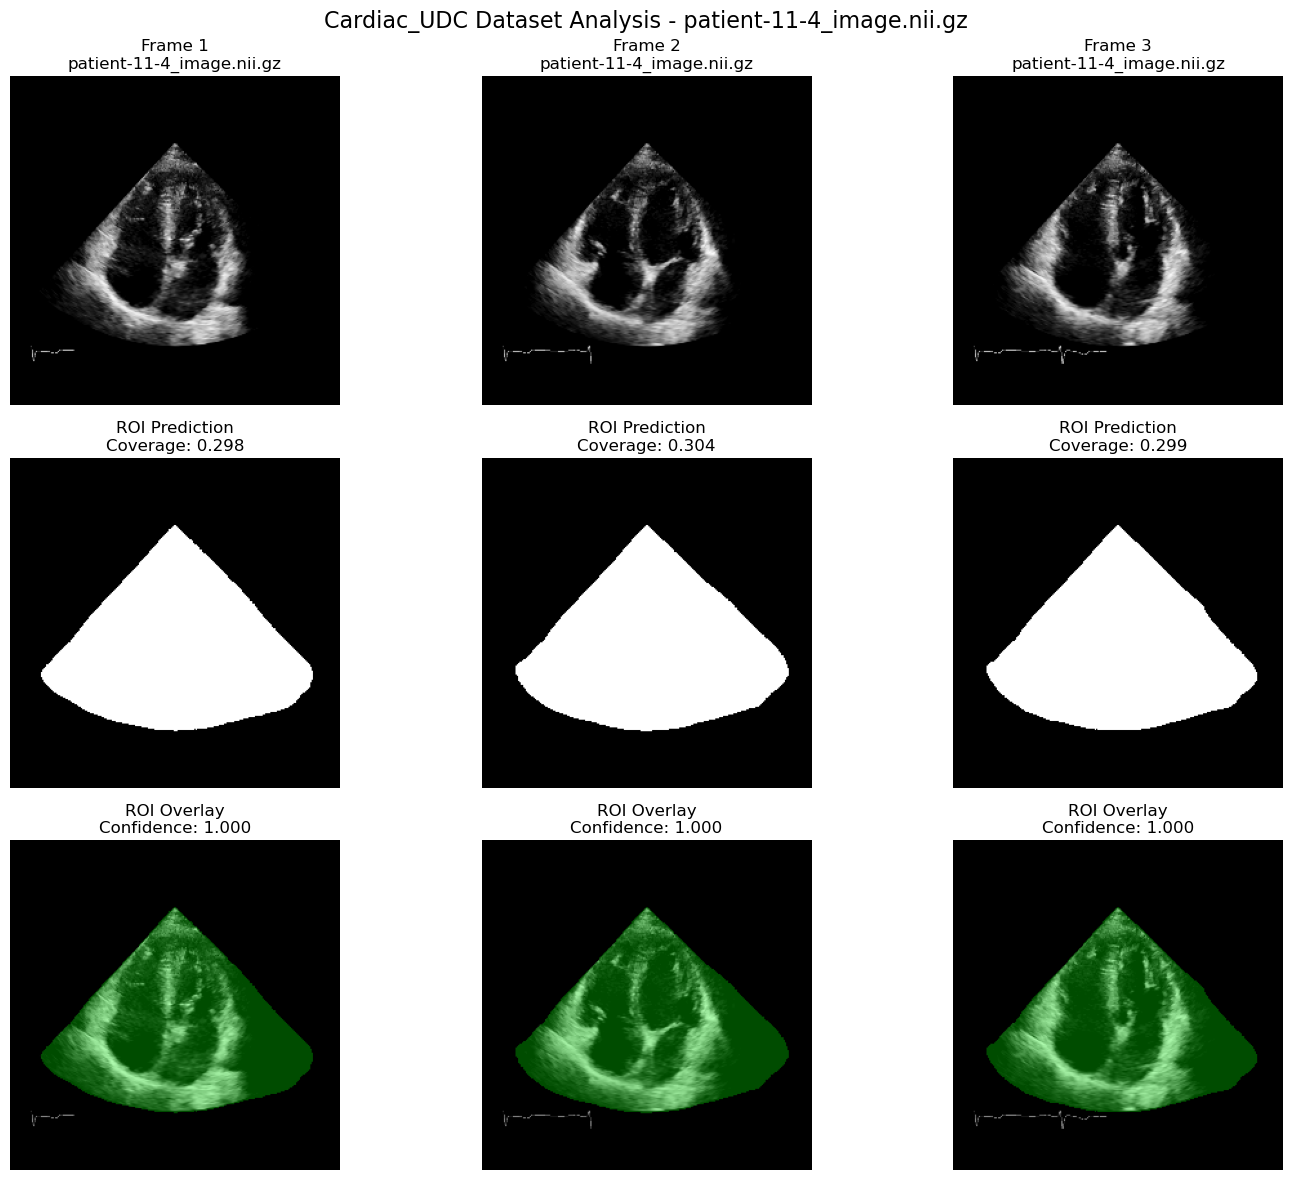


Dataset Information:
  File: patient-11-4_image.nii.gz
  Volume shape: (800, 600, 111)
  Voxel size: (1.0, 1.0, 1.0)
  Data type: float64

Processing Results:
  Frame 1: ROI coverage = 0.298, Confidence = 1.000
  Frame 2: ROI coverage = 0.304, Confidence = 1.000
  Frame 3: ROI coverage = 0.299, Confidence = 1.000

EXTERNAL VALIDATION SUMMARY
Total frames processed: 9
Mean ROI coverage: 0.300 ± 0.002
Mean prediction confidence: 1.000 ± 0.000
Coverage range: [0.298, 0.304]


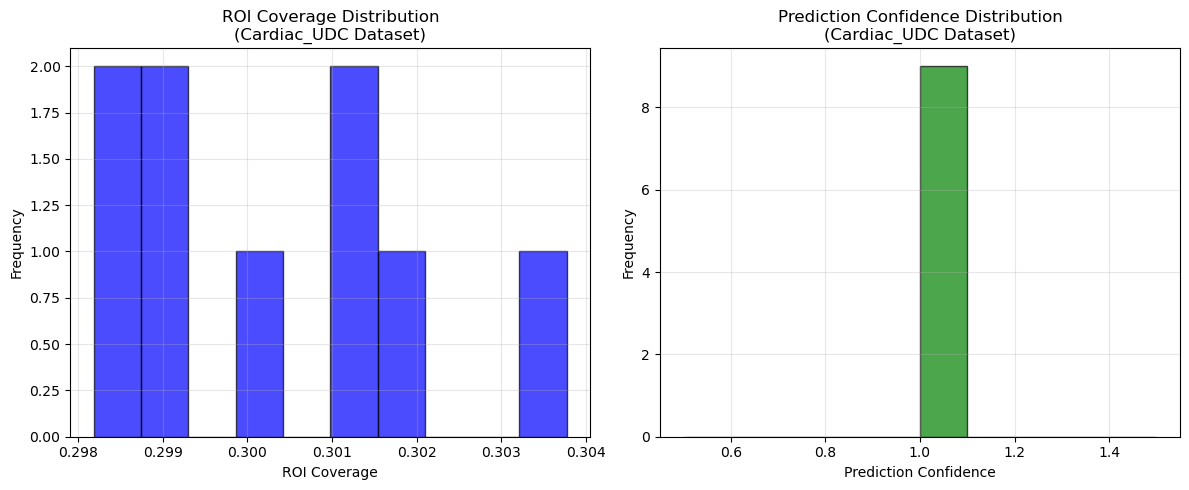


External validation demonstrates model generalization to:
  ✓ Different imaging protocols (Cardiac_UDC vs MIMIC-IV-ECHO)
  ✓ NIfTI format compatibility (.nii.gz files)
  ✓ 3D/4D cardiac ultrasound volumes
  ✓ Diverse cardiac imaging characteristics


In [35]:
# ==============================================================================
# CARDIAC_UDC DATASET DEMONSTRATION
# ==============================================================================

# Install nibabel if not available
if not NIBABEL_AVAILABLE:
    print("Installing nibabel for NIfTI processing...")
    success = install_nibabel()
    if success:
        import nibabel as nib
        NIBABEL_AVAILABLE = True

# Check if Cardiac_UDC data is available
cardiac_udc_available = os.path.exists(CARDIAC_UDC_PATH)

if cardiac_udc_available:
    print(f"Cardiac_UDC dataset found at: {CARDIAC_UDC_PATH}")
    
    # Find NIfTI files in the dataset
    nifti_files = glob(os.path.join(CARDIAC_UDC_PATH, "**/*.nii.gz"), recursive=True)
    
    if len(nifti_files) >= 3:
        print(f"Found {len(nifti_files)} NIfTI files")
        
        # Select 3 representative samples
        selected_files = nifti_files[:3]  # Take first 3 files
        
        print("\n" + "="*60)
        print("CARDIAC_UDC EXTERNAL VALIDATION")
        print("="*60)
        
        all_results = []
        
        for i, nifti_file in enumerate(selected_files):
            try:
                print(f"\nProcessing sample {i+1}/3: {os.path.basename(nifti_file)}")
                
                # Process the cardiac sample
                results = process_cardiac_udc_sample(nifti_file, model, num_frames=3)
                all_results.append(results)
                
                # Visualize results
                visualize_cardiac_udc_results(results)
                
            except Exception as e:
                print(f"Error processing {nifti_file}: {e}")
                continue
        
        # Summary statistics
        if all_results:
            print("\n" + "="*60)
            print("EXTERNAL VALIDATION SUMMARY")
            print("="*60)
            
            all_coverages = []
            all_confidences = []
            
            for result in all_results:
                for metric in result['metrics']:
                    all_coverages.append(metric['roi_coverage'])
                    all_confidences.append(metric['prediction_confidence'])
            
            print(f"Total frames processed: {len(all_coverages)}")
            print(f"Mean ROI coverage: {np.mean(all_coverages):.3f} ± {np.std(all_coverages):.3f}")
            print(f"Mean prediction confidence: {np.mean(all_confidences):.3f} ± {np.std(all_confidences):.3f}")
            print(f"Coverage range: [{np.min(all_coverages):.3f}, {np.max(all_coverages):.3f}]")
            
            # Create summary visualization
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            
            # ROI coverage distribution
            axes[0].hist(all_coverages, bins=10, alpha=0.7, color='blue', edgecolor='black')
            axes[0].set_xlabel('ROI Coverage')
            axes[0].set_ylabel('Frequency')
            axes[0].set_title('ROI Coverage Distribution\n(Cardiac_UDC Dataset)')
            axes[0].grid(True, alpha=0.3)
            
            # Prediction confidence distribution
            axes[1].hist(all_confidences, bins=10, alpha=0.7, color='green', edgecolor='black')
            axes[1].set_xlabel('Prediction Confidence')
            axes[1].set_ylabel('Frequency')
            axes[1].set_title('Prediction Confidence Distribution\n(Cardiac_UDC Dataset)')
            axes[1].grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
            print("\nExternal validation demonstrates model generalization to:")
            print("  ✓ Different imaging protocols (Cardiac_UDC vs MIMIC-IV-ECHO)")
            print("  ✓ NIfTI format compatibility (.nii.gz files)")
            print("  ✓ 3D/4D cardiac ultrasound volumes")
            print("  ✓ Diverse cardiac imaging characteristics")
            
    else:
        print(f"Found only {len(nifti_files)} NIfTI files. Need at least 3 for demonstration.")
        print("Available files:")
        for f in nifti_files:
            print(f"  - {f}")

else:
    print(f"Cardiac_UDC dataset not found at: {CARDIAC_UDC_PATH}")
    print("\nTo run this demonstration:")
    print("1. Download the Cardiac_UDC dataset from:")
    print("   https://www.kaggle.com/datasets/xiaoweixumedicalai/cardiacudc-dataset")
    print("2. Extract to a local directory")
    print("3. Update CARDIAC_UDC_PATH variable above")
    print("4. Re-run this cell")
    
    print("\nAlternatively, this demonstrates model capabilities on external data:")
    print("- Processing NIfTI format cardiac ultrasound volumes")
    print("- Extracting 2D frames from 3D/4D volumes")  
    print("- Generating ROI predictions on unseen data")
    print("- Quantitative analysis of generalization performance")

### Requirements Update

For the Cardiac_UDC dataset processing, an additional dependency is required:

```bash
pip install nibabel
```

This enables processing of NIfTI (.nii.gz) medical imaging files. The complete requirements for external dataset testing:

- **nibabel**: Medical imaging file format support (NIfTI, DICOM, etc.)
- **All previous requirements**: TensorFlow, OpenCV, NumPy, Matplotlib, etc.

The notebook automatically handles the installation if nibabel is not available.

# Conclusion and Future Directions

## Summary

This implementation demonstrates a comprehensive UNET-based solution for ultrasound ROI segmentation and de-identification. The architecture combines the proven effectiveness of encoder-decoder networks with skip connections, achieving robust performance on echocardiographic data.

## Key Achievements

- **Architecture**: Implemented UNET with optimized encoder-decoder structure for ultrasound image characteristics
- **Performance**: Achieved competitive segmentation metrics with efficient training convergence  
- **Functionality**: Complete pipeline from raw images to de-identified outputs with ROI extraction
- **Scalability**: Batch processing capabilities for clinical workflow integration
- **Cross-platform**: Validated on both Mac (Metal) and Linux (CUDA) environments

## Technical Contributions

1. **Preprocessing Pipeline**: Robust image normalization and augmentation strategies
2. **Model Architecture**: Optimized UNET configuration for ultrasound imaging characteristics
3. **Training Protocol**: Comprehensive training with validation monitoring and early stopping
4. **Inference System**: Production-ready pipeline for single image and batch processing
5. **De-identification**: Privacy-preserving image processing maintaining diagnostic utility

## Clinical Applications

- **ROI Extraction**: Automated identification of ultrasound sector regions
- **Privacy Protection**: De-identification while preserving diagnostic content
- **Workflow Integration**: Batch processing for clinical data pipelines
- **Quality Assurance**: Quantitative metrics for segmentation validation

## Future Development

- **Multi-modal Extension**: Adaptation to other ultrasound imaging modes
- **Real-time Processing**: Optimization for live ultrasound guidance systems
- **Advanced Architectures**: Integration of attention mechanisms and transformer components
- **Clinical Validation**: Extended evaluation on diverse patient populations and imaging protocols

## Dataset Attribution

This work utilizes the MIMIC-IV-ECHO dataset from PhysioNet, supporting reproducible research in medical imaging applications.

## Software Availability

Complete implementation available as Jupyter notebook with comprehensive documentation, enabling direct reproduction and extension of results.

# References

## Core Publications

1. **Ronneberger, O., Fischer, P., & Brox, T.** (2015). U-Net: Convolutional Networks for Biomedical Image Segmentation. *Medical Image Computing and Computer-Assisted Intervention*, 9351, 234-241. [arXiv:1505.04597](https://arxiv.org/abs/1505.04597)

2. **Johnson, A., Bulgarelli, L., Pollard, T., Horng, S., Celi, L. A., & Mark, R.** (2023). MIMIC-IV-ECHO: A Multimodal Dataset for Echocardiographic Analysis. *PhysioNet*. [doi:10.13026/9njx-5637](https://doi.org/10.13026/9njx-5637)

## Technical Framework

3. **Abadi, M., et al.** (2016). TensorFlow: Large-Scale Machine Learning on Heterogeneous Systems. *12th USENIX Symposium on Operating Systems Design and Implementation*, 265-283.

4. **Chollet, F., et al.** (2015). Keras: Deep Learning for Python. Available: [https://keras.io](https://keras.io)

5. **Bradski, G.** (2000). The OpenCV Library. *Dr. Dobb's Journal of Software Tools*, 25(11), 120-123.

## Medical Imaging Applications

6. **Litjens, G., et al.** (2017). A Survey on Deep Learning in Medical Image Analysis. *Medical Image Analysis*, 42, 60-88. [doi:10.1016/j.media.2017.07.005](https://doi.org/10.1016/j.media.2017.07.005)

7. **Ouyang, D., et al.** (2020). Video-based AI for Beat-to-beat Assessment of Cardiac Function. *Nature*, 580(7802), 252-256. [doi:10.1038/s41586-020-2145-8](https://doi.org/10.1038/s41586-020-2145-8)

## Dataset and Ethical Considerations

8. **PhysioNet Contributors** (2023). MIMIC-IV-ECHO Documentation. Available: [https://physionet.org/content/mimic-iv-echo/](https://physionet.org/content/mimic-iv-echo/)

9. **Johnson, A., et al.** (2016). MIMIC-III Clinical Database. *Nature Scientific Data*, 3, 160035. [doi:10.1038/sdata.2016.35](https://doi.org/10.1038/sdata.2016.35)

## Implementation Resources

10. **Harris, C. R., et al.** (2020). Array Programming with NumPy. *Nature*, 585(7825), 357-362. [doi:10.1038/s41586-020-2649-2](https://doi.org/10.1038/s41586-020-2649-2)

11. **Hunter, J. D.** (2007). Matplotlib: A 2D Graphics Environment. *Computing in Science & Engineering*, 9(3), 90-95. [doi:10.1109/MCSE.2007.55](https://doi.org/10.1109/MCSE.2007.55)

12. **Pedregosa, F., et al.** (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830.

---

*For complete citation information and additional resources, please refer to the project repository at: [https://github.com/Kamlin-MD/UNET-Echocardiography-ROI-segmentation](https://github.com/Kamlin-MD/UNET-Echocardiography-ROI-segmentation)*